# E1 — Cuantización: BPW en Llama-3.2-3B

## Pregunta de investigación

¿Cómo afecta la cuantización (BPW) al rendimiento y eficiencia?

## Hipótesis previa

Mayor cuantización (menor BPW) reduce memoria pero puede impactar throughput y perplejidad.

Algunos modelos dependiendo del tipo de cuantización, pueden "colapsar".

## Configuración del experimento

| Parámetro | Valores           |
|-----------|-------------------|
| Modelos | Llama-3.2-3B      |
| Cuantización (BPW) | 3,4, 5, 6, 8 bits |
| Total | Múltiples runs    |

In [1]:
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from monitorviz.io import load_collection
from monitorviz.transforms.collection import RunCollection
from monitorviz.viz import setup_style

setup_style("talk")
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# ── Carga de datos (E1) ───────────────────────────────────────────────────────
_here = Path.cwd()
PROJECT_ROOT = _here.parent if _here.name == "notebooks" else _here
DATA_ROOT = PROJECT_ROOT / "data" / "tfg-data" / "E1"
assert DATA_ROOT.is_dir(), f"No encontrado: {DATA_ROOT.resolve()}"

coll_raw = load_collection(DATA_ROOT)
print(f"Runs cargados (total): {len(coll_raw)}")

# ── Exclusión temprana de runs inválidos (ANTES de construir DataFrames) ──────
# DeepSeek Q4_0 y Q8_0 producen colapso de generación (bucle ASCII / cadena
# vacía). Sus métricas de perplejidad y throughput son inválidas.
# NOTA: model_info.architecture = "qwen2" para DeepSeek (arquitectura base),
# por eso la comprobación usa model_short, que sí contiene "DeepSeek".

def _is_invalid_run(run) -> bool:
    """Devuelve True si el run debe ser excluido del análisis E1."""
    try:
        mi    = run.summary.model_info or {}
        quant = (mi.get("quantization") or "").upper()
        if not quant:
            quant = run.model_short.upper()
        is_deepseek  = "deepseek" in run.model_short.lower()
        is_bad_quant = quant in {"Q4_0", "Q8_0"}
        return is_deepseek and is_bad_quant
    except Exception:
        return False

invalid_runs = [r for r in coll_raw.runs if _is_invalid_run(r)]
valid_runs   = [r for r in coll_raw.runs if not _is_invalid_run(r)]

if invalid_runs:
    ids = [r.run_id for r in invalid_runs]
    print(f"Runs excluidos (DeepSeek Q4_0/Q8_0, datos inválidos): {len(invalid_runs)}")
    print(f"  IDs: {ids}")
else:
    print("Sin runs excluidos.")

coll = RunCollection(valid_runs)
print(f"Runs en análisis: {len(coll)}")

# ── DataFrames (solo sobre runs válidos) ─────────────────────────────────────
summary  = coll.summary_df()
hw_full  = coll.hw_metrics_df()
pm_full  = coll.prompt_metrics_df()

# ── Columna quantization (extraída de model_info, clave para el sistema visual)
if "quantization" not in summary.columns:
    summary["quantization"] = [
        (r.summary.model_info or {}).get("quantization")
        for r in coll.runs
    ]

# ── bits_per_weight (lookup si OLLAMA no lo reporta) ─────────────────────────
if "bits_per_weight" not in summary.columns:
    try:
        from monitorviz.transforms.aggregations import _GGUF_BPW
        bpw_list = []
        for r in coll.runs:
            mi  = r.summary.model_info
            bpw = None
            if mi:
                bpw = mi.get("bits_per_weight") or _GGUF_BPW.get(
                    (mi.get("quantization") or "").upper()
                )
            bpw_list.append(bpw)
        summary["bits_per_weight"] = bpw_list
    except Exception as e:
        print(f"bits_per_weight no disponible: {e}")

# Alias para compatibilidad con celdas posteriores
ex = summary

# ── Sistema de codificación visual ────────────────────────────────────────────
# Colores por cuantización: ColorBrewer Set1.
# Los non-K (Q4_0, Q8_0) usan rojo/morado para distinguirlos visualmente
# de los K-quants, cuya calidad por bit es superior.
QUANT_ORDER  = ["Q2_K", "Q3_K_M", "Q4_0", "Q4_K_M", "Q5_K_M", "Q6_K", "Q8_0", "BF16"]
QUANT_COLORS = {
    "Q2_K":   "#a65628",  # marrón   – máxima compresión K
    "Q3_K_M": "#377eb8",  # azul
    "Q4_0":   "#e41a1c",  # rojo     – non-K
    "Q4_K_M": "#ff7f00",  # naranja
    "Q5_K_M": "#4daf4a",  # verde
    "Q6_K":   "#f781bf",  # rosa
    "Q8_0":   "#984ea3",  # morado   – non-K
    "BF16":   "#999999",  # gris     – referencia de precisión
}
QUANT_BPW = {
    "Q2_K": 2.6, "Q3_K_M": 3.35, "Q4_0": 4.0, "Q4_K_M": 4.5,
    "Q5_K_M": 5.5, "Q6_K": 6.6,  "Q8_0": 8.0, "BF16":  16.0,
}

# Marcadores por modelo: asignación estable, orden alfabético del label.
_MARKER_POOL = ["o", "s", "^", "D", "v", "P", "X", "*"]
MODEL_MARKERS = {
    m: _MARKER_POOL[i % len(_MARKER_POOL)]
    for i, m in enumerate(sorted(ex["model_label"].unique()))
}

print(f"Cuantizaciones: {sorted(ex['quantization'].dropna().unique())}")
print(f"Modelos → marcadores:")
for m, mk in MODEL_MARKERS.items():
    print(f"  {m!r:35s} → '{mk}'")

Non-positive prob en LLAMA tokenProb: 3938 tokens omitidos (run=1779665414914478319, prompt=0). Run posiblemente corrupto.
Non-positive prob en LLAMA tokenProb: 4018 tokens omitidos (run=1779665414914478319, prompt=1). Run posiblemente corrupto.
Non-positive prob en LLAMA tokenProb: 4016 tokens omitidos (run=1779665414914478319, prompt=2). Run posiblemente corrupto.
Non-positive prob en LLAMA tokenProb: 3937 tokens omitidos (run=1779665414914478319, prompt=3). Run posiblemente corrupto.
Non-positive prob en LLAMA tokenProb: 4014 tokens omitidos (run=1779665414914478319, prompt=4). Run posiblemente corrupto.
Non-positive prob en LLAMA tokenProb: 3929 tokens omitidos (run=1779665414914478319, prompt=5). Run posiblemente corrupto.
Non-positive prob en LLAMA tokenProb: 4010 tokens omitidos (run=1779665414914478319, prompt=6). Run posiblemente corrupto.
Non-positive prob en LLAMA tokenProb: 4002 tokens omitidos (run=1779665414914478319, prompt=7). Run posiblemente corrupto.
Non-positive pro

Runs cargados (total): 31
Runs excluidos (DeepSeek Q4_0/Q8_0, datos inválidos): 2
  IDs: ['1779646345987451801', '1779665414914478319']
Runs en análisis: 29
Cuantizaciones: ['BF16', 'Q3_K_M', 'Q4_0', 'Q4_K_M', 'Q5_K_M', 'Q8_0']
Modelos → marcadores:
  'DeepSeek-R1-1.5B (L)'              → 'o'
  'Llama-3.2-1B (L)'                  → 's'
  'Llama-3.2-3B (L)'                  → '^'
  'gemma (L)'                         → 'D'
  'granite (L)'                       → 'v'
  'ministral (L)'                     → 'P'


In [2]:
# Sistema visual E1: quant_label, _ql_map, helpers de scatter
# QUANT_ORDER / QUANT_COLORS / QUANT_BPW / MODEL_MARKERS definidos en la celda de Setup.
from matplotlib.lines import Line2D as _Line2D

_q_col   = "quantization" if "quantization" in ex.columns else "model_short"
_q_col_s = _q_col
ex["quant_label"] = ex["model_label"] + "\n(" + ex[_q_col].fillna("?") + ")"
_ql_map  = ex.set_index("run_id")["quant_label"].to_dict()
print("quant_labels detectados:")
print(ex[["model_label", _q_col, "quant_label"]].drop_duplicates().to_string(index=False))


def scatter_e1(ax, data, x_col, y_col, xlabel, ylabel, title):
    for _, row in data.iterrows():
        q      = str(row.get(_q_col_s, "?"))
        m      = row["model_label"]
        color  = QUANT_COLORS.get(q, "gray")
        marker = MODEL_MARKERS.get(m, "o")
        ax.scatter(row[x_col], row[y_col], color=color, marker=marker, s=100, zorder=3)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)


def add_e1_legend(ax, quants, models):
    quant_handles = [
        _Line2D([0], [0], marker="o", color="w",
                markerfacecolor=QUANT_COLORS.get(q, "gray"), markersize=9, label=q)
        for q in quants
    ]
    sep = _Line2D([0], [0], color="none", label="")
    model_handles = [
        _Line2D([0], [0], marker=MODEL_MARKERS.get(m, "o"), color="gray",
                markersize=9, linestyle="None", label=m)
        for m in models
    ]
    ax.legend(
        handles=quant_handles + [sep] + model_handles,
        loc="upper left", bbox_to_anchor=(1.02, 1),
        title="Color=cuant / Forma=modelo", fontsize=8, title_fontsize=8,
    )


print("Sistema visual E1 listo.")

quant_labels detectados:
         model_label quantization                    quant_label
DeepSeek-R1-1.5B (L)       Q3_K_M DeepSeek-R1-1.5B (L)\n(Q3_K_M)
DeepSeek-R1-1.5B (L)       Q4_K_M DeepSeek-R1-1.5B (L)\n(Q4_K_M)
DeepSeek-R1-1.5B (L)       Q5_K_M DeepSeek-R1-1.5B (L)\n(Q5_K_M)
         granite (L)       Q3_K_M          granite (L)\n(Q3_K_M)
         granite (L)         Q4_0            granite (L)\n(Q4_0)
         granite (L)       Q4_K_M          granite (L)\n(Q4_K_M)
         granite (L)       Q5_K_M          granite (L)\n(Q5_K_M)
         granite (L)         Q8_0            granite (L)\n(Q8_0)
    Llama-3.2-1B (L)         BF16       Llama-3.2-1B (L)\n(BF16)
    Llama-3.2-1B (L)       Q3_K_M     Llama-3.2-1B (L)\n(Q3_K_M)
    Llama-3.2-1B (L)         Q4_0       Llama-3.2-1B (L)\n(Q4_0)
    Llama-3.2-1B (L)       Q4_K_M     Llama-3.2-1B (L)\n(Q4_K_M)
    Llama-3.2-1B (L)       Q5_K_M     Llama-3.2-1B (L)\n(Q5_K_M)
    Llama-3.2-1B (L)         Q8_0       Llama-3.2-1B (L)\n(Q8_0)


## Resumen ejecutivo
> TODO: Actualizar con resultados finales.

## Advertencia: DeepSeek + non-K-quants

> **Hipótesis a verificar:** Los runs de `DeepSeek-R1-Distill-Qwen-1.5B` con cuantizaciones **Q4_0 y Q8_0** producen respuestas inválidas (bucle de caracteres ASCII o cadena vacía) en lugar de texto coherente. Los runs con K-quants (Q3_K_M, Q4_K_M, Q5_K_M) funcionan correctamente.

**Causa probable:** Los modelos destilados de DeepSeek-R1 tienen distribuciones de pesos con outliers pronunciados. Las cuantizaciones **no-K** (`Q4_0`, `Q8_0`) aplican un esquema uniforme por bloques que destruye esos outliers, provocando colapso de la generación. Las **K-quants** (`_K_M`, `_K_S`) usan precisión mixta por capa y preservan los valores críticos.

**Impacto en el análisis:**
- Las métricas de inferencia (tokens/s, perplejidad) de Q4_0 y Q8_0 para DeepSeek son **inválidas**.
- Considerar **excluirlos** del análisis comparativo de E1 para ese modelo.

**Patrón observado en los datos:**
```
Q4_0 → respuesta = '!"#$%&\'()*+,-./...'
Q8_0 → respuesta = '' (vacía) o 2-3 tokens
Q3_K_M / Q4_K_M / Q5_K_M → respuesta coherente
```

In [3]:
# Tabla comparativa — métricas de inferencia y hardware
_q_col_t = "quantization" if "quantization" in ex.columns else "model_short"
display_cols = [
    "model_label", _q_col_t, "engine",
    "tokens_per_s_mean", "words_per_s_mean",
    "latency_ms_mean", "ttft_ms_mean",
    "perplexity_geomean",
]
cols = [c for c in display_cols if c in ex.columns]
if not ex.empty:
    _sort_key = "bits_per_weight" if "bits_per_weight" in ex.columns else cols[0]
    display(ex.sort_values(_sort_key)[cols].round(3))
else:
    print("Sin datos")

eff_cols = [
    "model_label", _q_col_t, "engine",
    "temp_max_c", "temp_mean_c",
    "power_mean_w", "power_max_w",
    "throttled_ratio",
    "energy_per_token_j", "cpu_work_core_s", "cpu_efficiency",
]
eff_cols = [c for c in eff_cols if c in ex.columns]
if not ex.empty and eff_cols:
    _sort_key2 = "bits_per_weight" if "bits_per_weight" in ex.columns else eff_cols[0]
    display(ex.sort_values(_sort_key2)[eff_cols].round(3))


,model_label,quantization,engine,tokens_per_s_mean,words_per_s_mean,latency_ms_mean,ttft_ms_mean,perplexity_geomean
3,granite (L),Q3_K_M,LLAMA,5.184,3.819,70843.912,4526.218,2.935
0,DeepSeek-R1-1.5B (L),Q3_K_M,LLAMA,9.930,8.285,349771.126,1811.995,2.329
19,ministral (L),Q3_K_M,LLAMA,5.520,3.895,181118.302,3628.804,3.118
14,Llama-3.2-3B (L),Q3_K_M,LLAMA,5.433,4.215,397160.988,3558.464,2.359
9,Llama-3.2-1B (L),Q3_K_M,LLAMA,11.395,8.953,286586.579,1300.641,1.981
4,granite (L),Q4_0,LLAMA,4.548,3.462,74051.410,1585.729,3.082
20,ministral (L),Q4_0,LLAMA,5.099,3.517,183330.100,1161.909,3.065
15,Llama-3.2-3B (L),Q4_0,LLAMA,5.413,4.156,185788.707,1077.115,2.902
5,granite (L),Q4_K_M,LLAMA,4.409,3.401,88508.642,2347.802,2.854
10,Llama-3.2-1B (L),Q4_0,LLAMA,11.156,8.711,240988.504,462.620,2.058


,model_label,quantization,engine,temp_max_c,temp_mean_c,power_mean_w,power_max_w,throttled_ratio,energy_per_token_j,cpu_work_core_s,cpu_efficiency
3,granite (L),Q3_K_M,LLAMA,75.45,71.637,7.840,9.707,0.0,1.512,4200.294,0.970
0,DeepSeek-R1-1.5B (L),Q3_K_M,LLAMA,75.45,71.730,7.440,9.698,0.0,0.749,20474.912,0.973
19,ministral (L),Q3_K_M,LLAMA,76.00,71.847,7.876,9.969,0.0,1.427,10024.097,0.977
14,Llama-3.2-3B (L),Q3_K_M,LLAMA,76.55,68.021,7.180,9.759,0.0,1.321,23613.203,0.987
9,Llama-3.2-1B (L),Q3_K_M,LLAMA,71.60,67.244,6.989,9.701,0.0,0.613,16828.348,0.976
4,granite (L),Q4_0,LLAMA,68.85,64.701,6.460,9.280,0.0,1.420,4393.119,0.969
20,ministral (L),Q4_0,LLAMA,69.40,65.170,6.543,9.401,0.0,1.283,10874.909,0.979
15,Llama-3.2-3B (L),Q4_0,LLAMA,69.95,65.643,6.638,9.394,0.0,1.226,11024.725,0.980
5,granite (L),Q4_K_M,LLAMA,69.95,65.922,6.693,9.196,0.0,1.518,5243.990,0.968
10,Llama-3.2-1B (L),Q4_0,LLAMA,69.40,64.786,6.264,8.984,0.0,0.561,14158.189,0.976


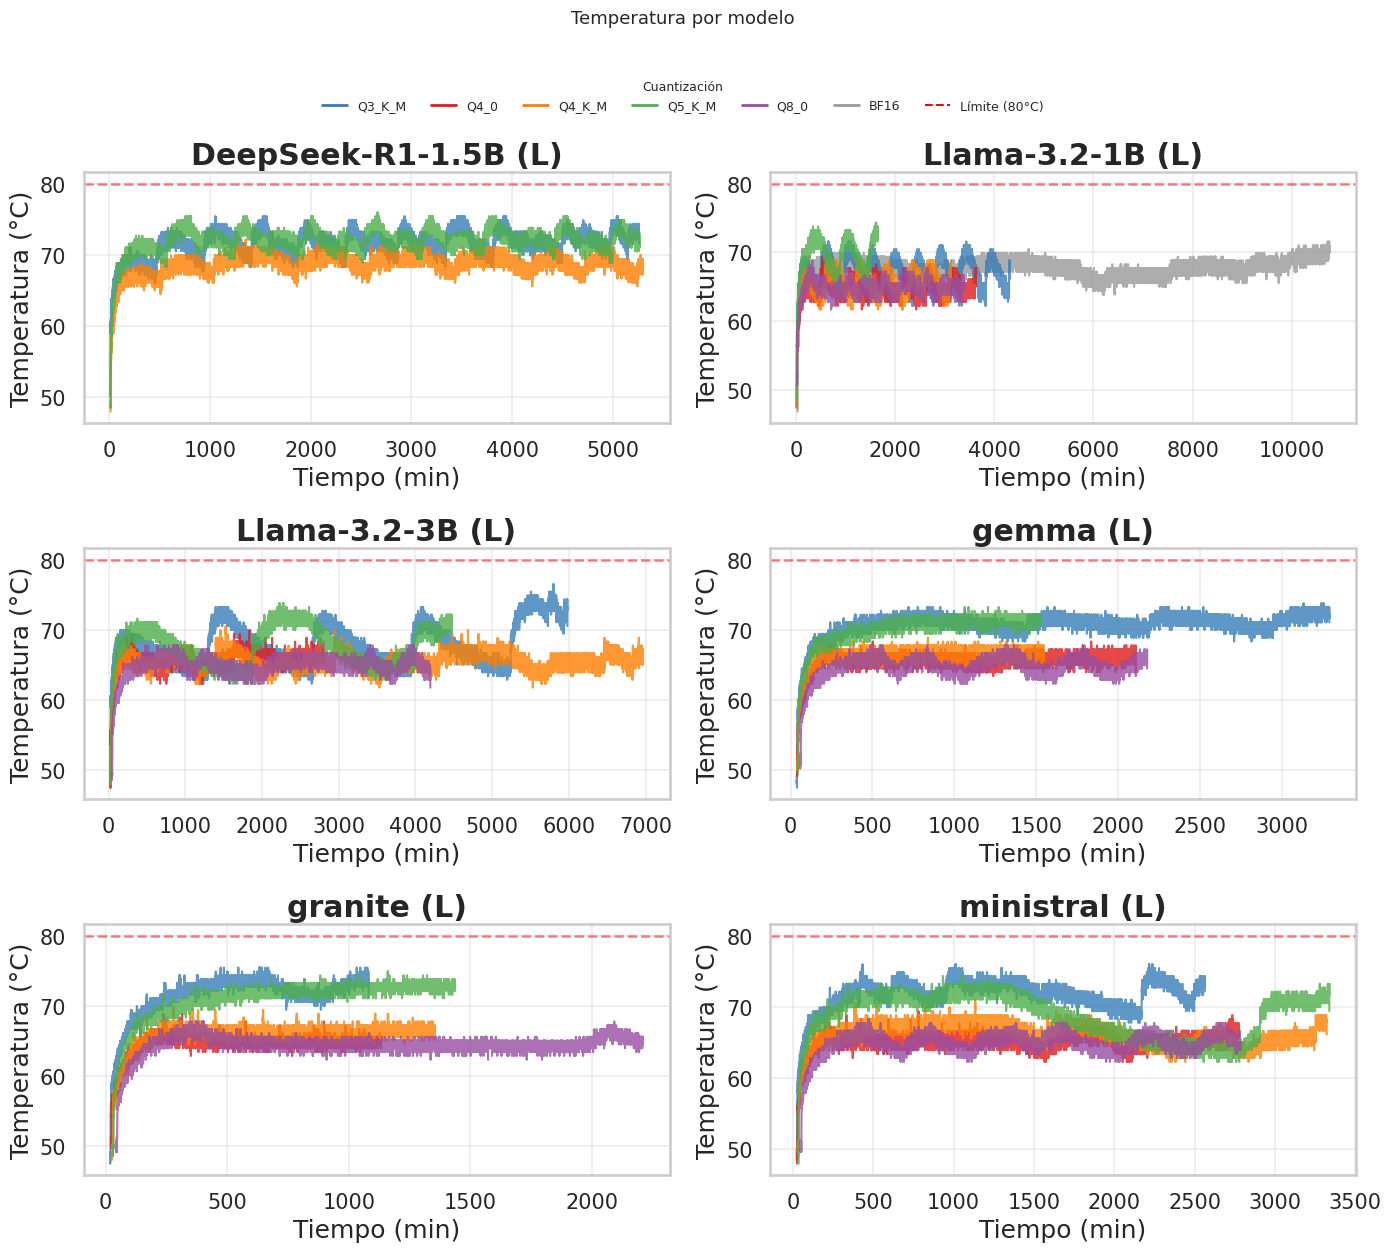

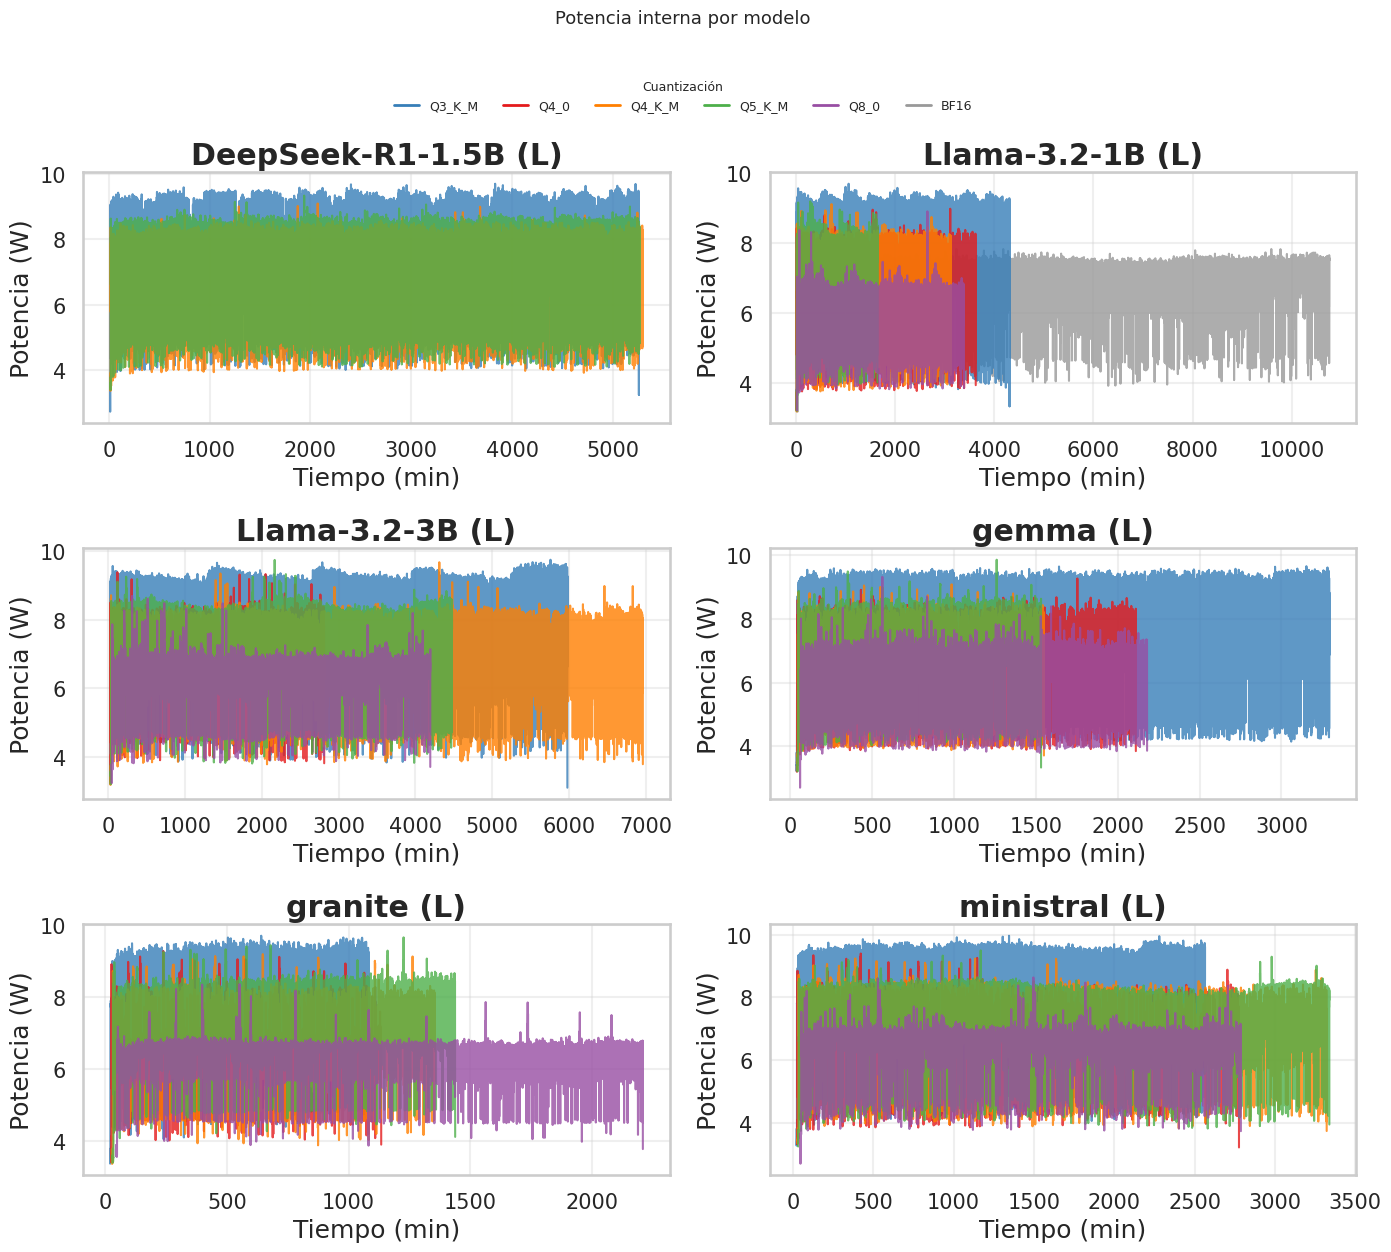

In [4]:
# Timelines de temperatura y potencia (small multiples, 2 columnas)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

# Mapa run_id → quantization para colorear las líneas
_q_col_tl = "quantization" if "quantization" in ex.columns else "model_short"
_rid_to_quant = ex.set_index("run_id")[_q_col_tl].to_dict() if "run_id" in ex.columns else {}

def _plot_timeline(hw_ex, models, y_col, ylabel, suptitle, hline=None):
    from matplotlib.lines import Line2D as _L2D
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]
    quants_seen = []
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            q = _rid_to_quant.get(rid, "")
            color = QUANT_COLORS.get(q, None)
            if q and q not in quants_seen:
                quants_seen.append(q)
            ax.plot(sub["t_rel_s"].values, sub[y_col].values,
                    color=color, alpha=0.8, linewidth=1.5)
        if hline is not None:
            ax.axhline(hline, ls="--", color="red", alpha=0.5, label=f"Límite ({hline}°C)")
        total_s = hw_m["t_rel_s"].max()
        ax.set_xlabel("Tiempo (min)" if total_s > 1800 else "Tiempo (s)")
        ax.set_ylabel(ylabel)
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    # Leyenda de cuantizaciones bajo el título
    quants_ordered = [q for q in QUANT_ORDER if q in quants_seen]
    quants_ordered += [q for q in quants_seen if q not in quants_ordered]
    handles = [
        _L2D([0], [0], color=QUANT_COLORS.get(q, "gray"), lw=2, label=q)
        for q in quants_ordered
    ]
    if hline is not None:
        handles.append(_L2D([0], [0], color="red", lw=1.5, ls="--", label=f"Límite ({hline}°C)"))
    fig.legend(
        handles=handles, loc="upper center",
        ncol=len(handles), fontsize=9,
        title="Cuantización", title_fontsize=9,
        bbox_to_anchor=(0.5, 1.0),
    )
    fig.suptitle(suptitle, fontsize=13, y=1.05)
    fig.tight_layout()
    plt.show()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    _plot_timeline(hw_ex, models, "temperature_c", "Temperatura (°C)",
                   "Temperatura por modelo", hline=80)
    _plot_timeline(hw_ex, models, "internal_power_w", "Potencia (W)",
                   "Potencia interna por modelo")
else:
    print("Sin datos de hardware para timelines")


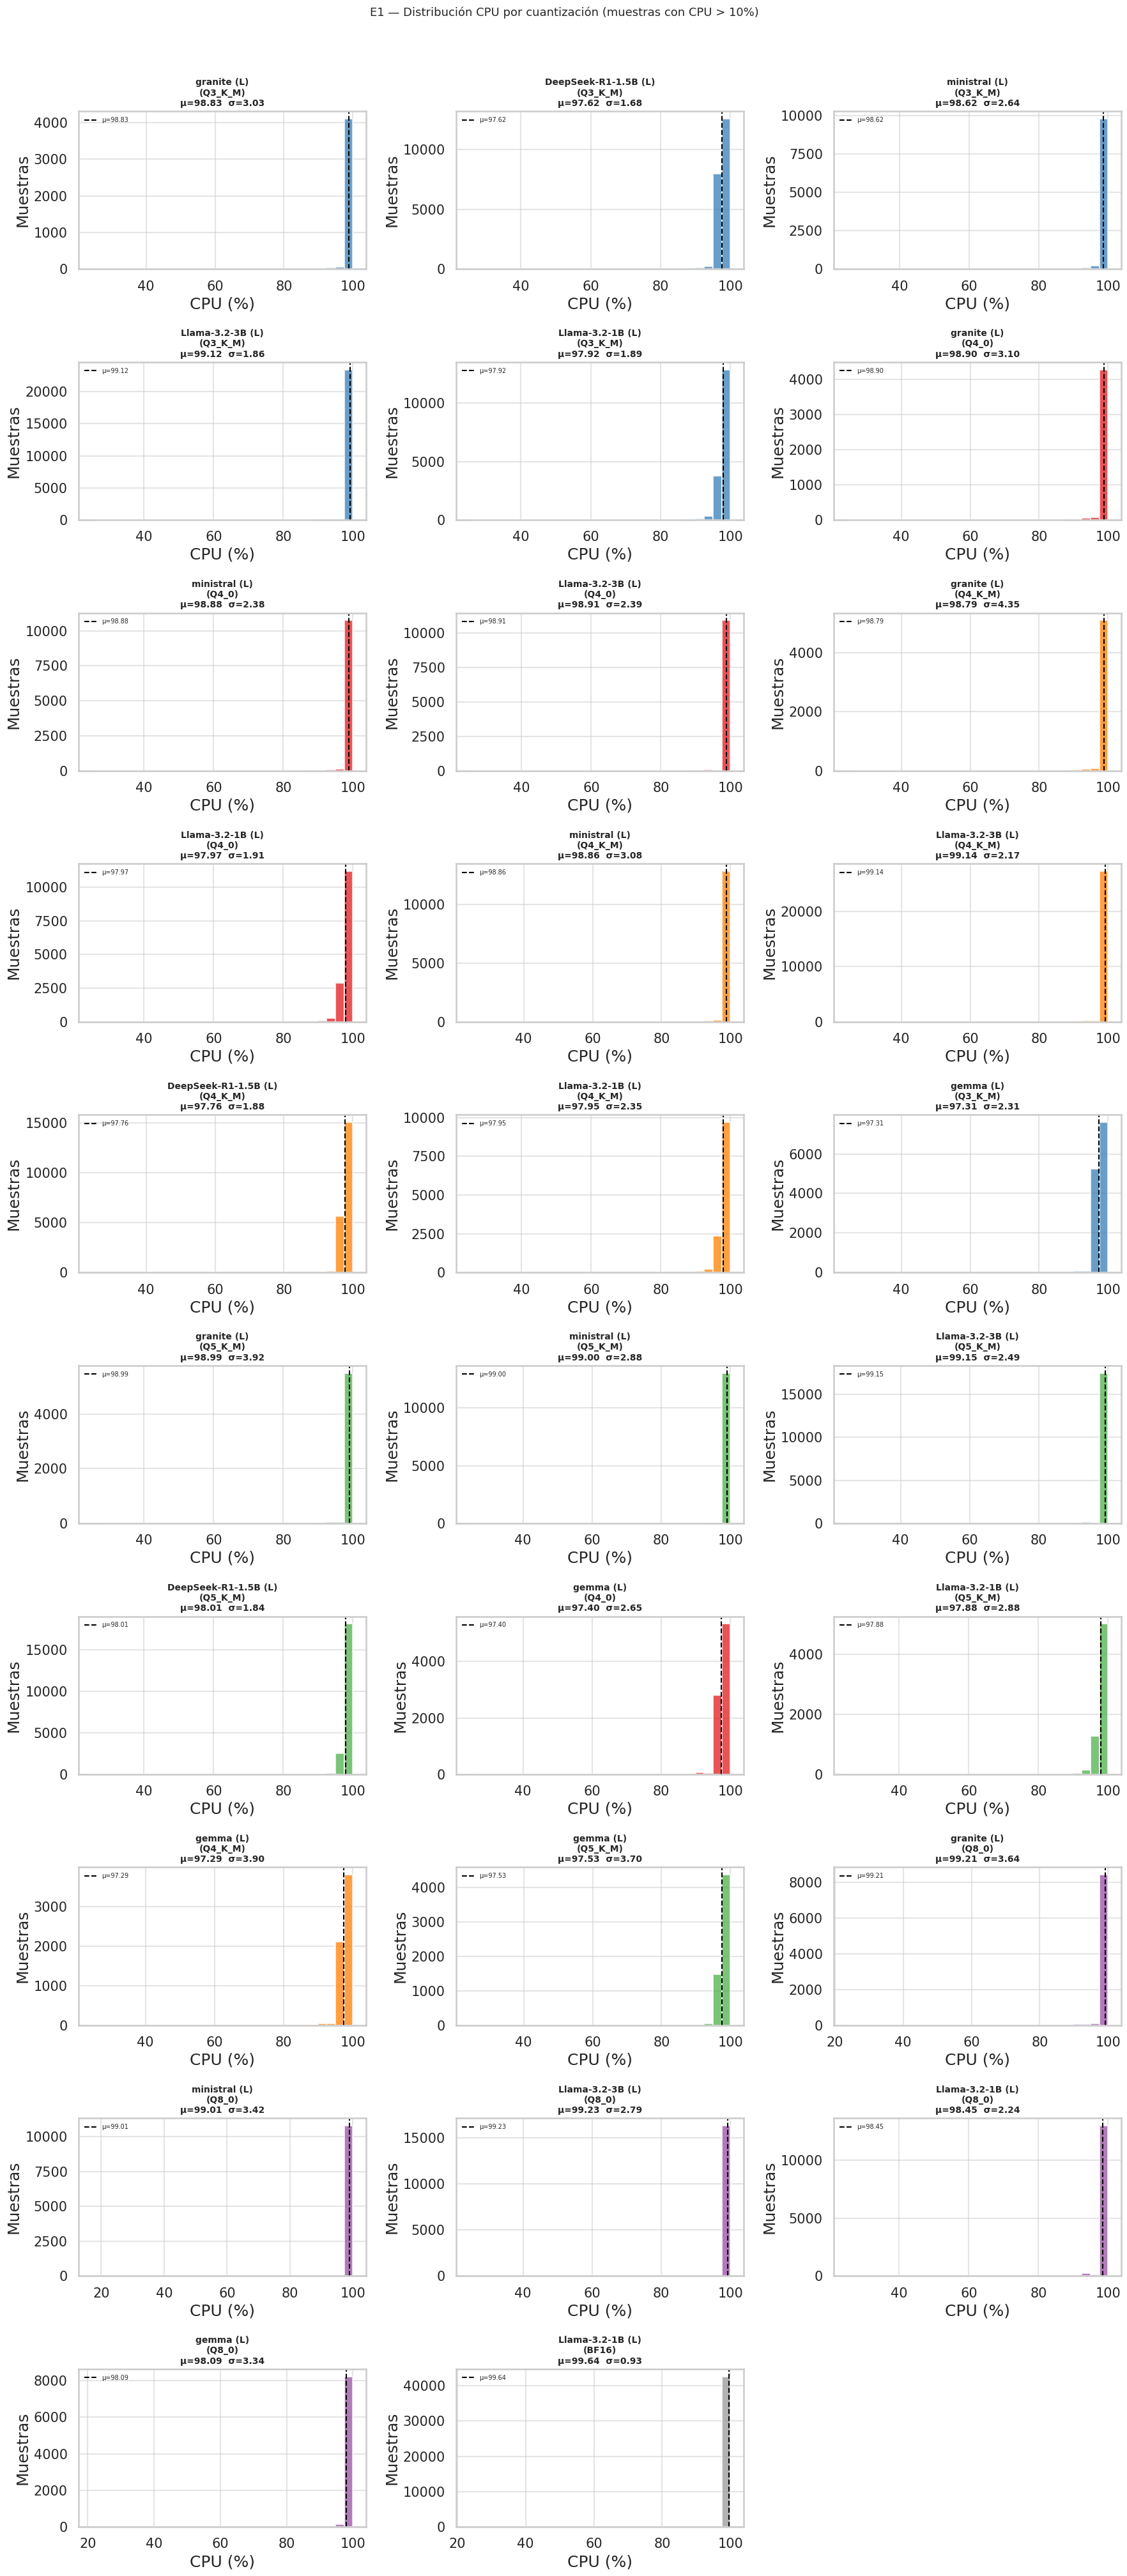

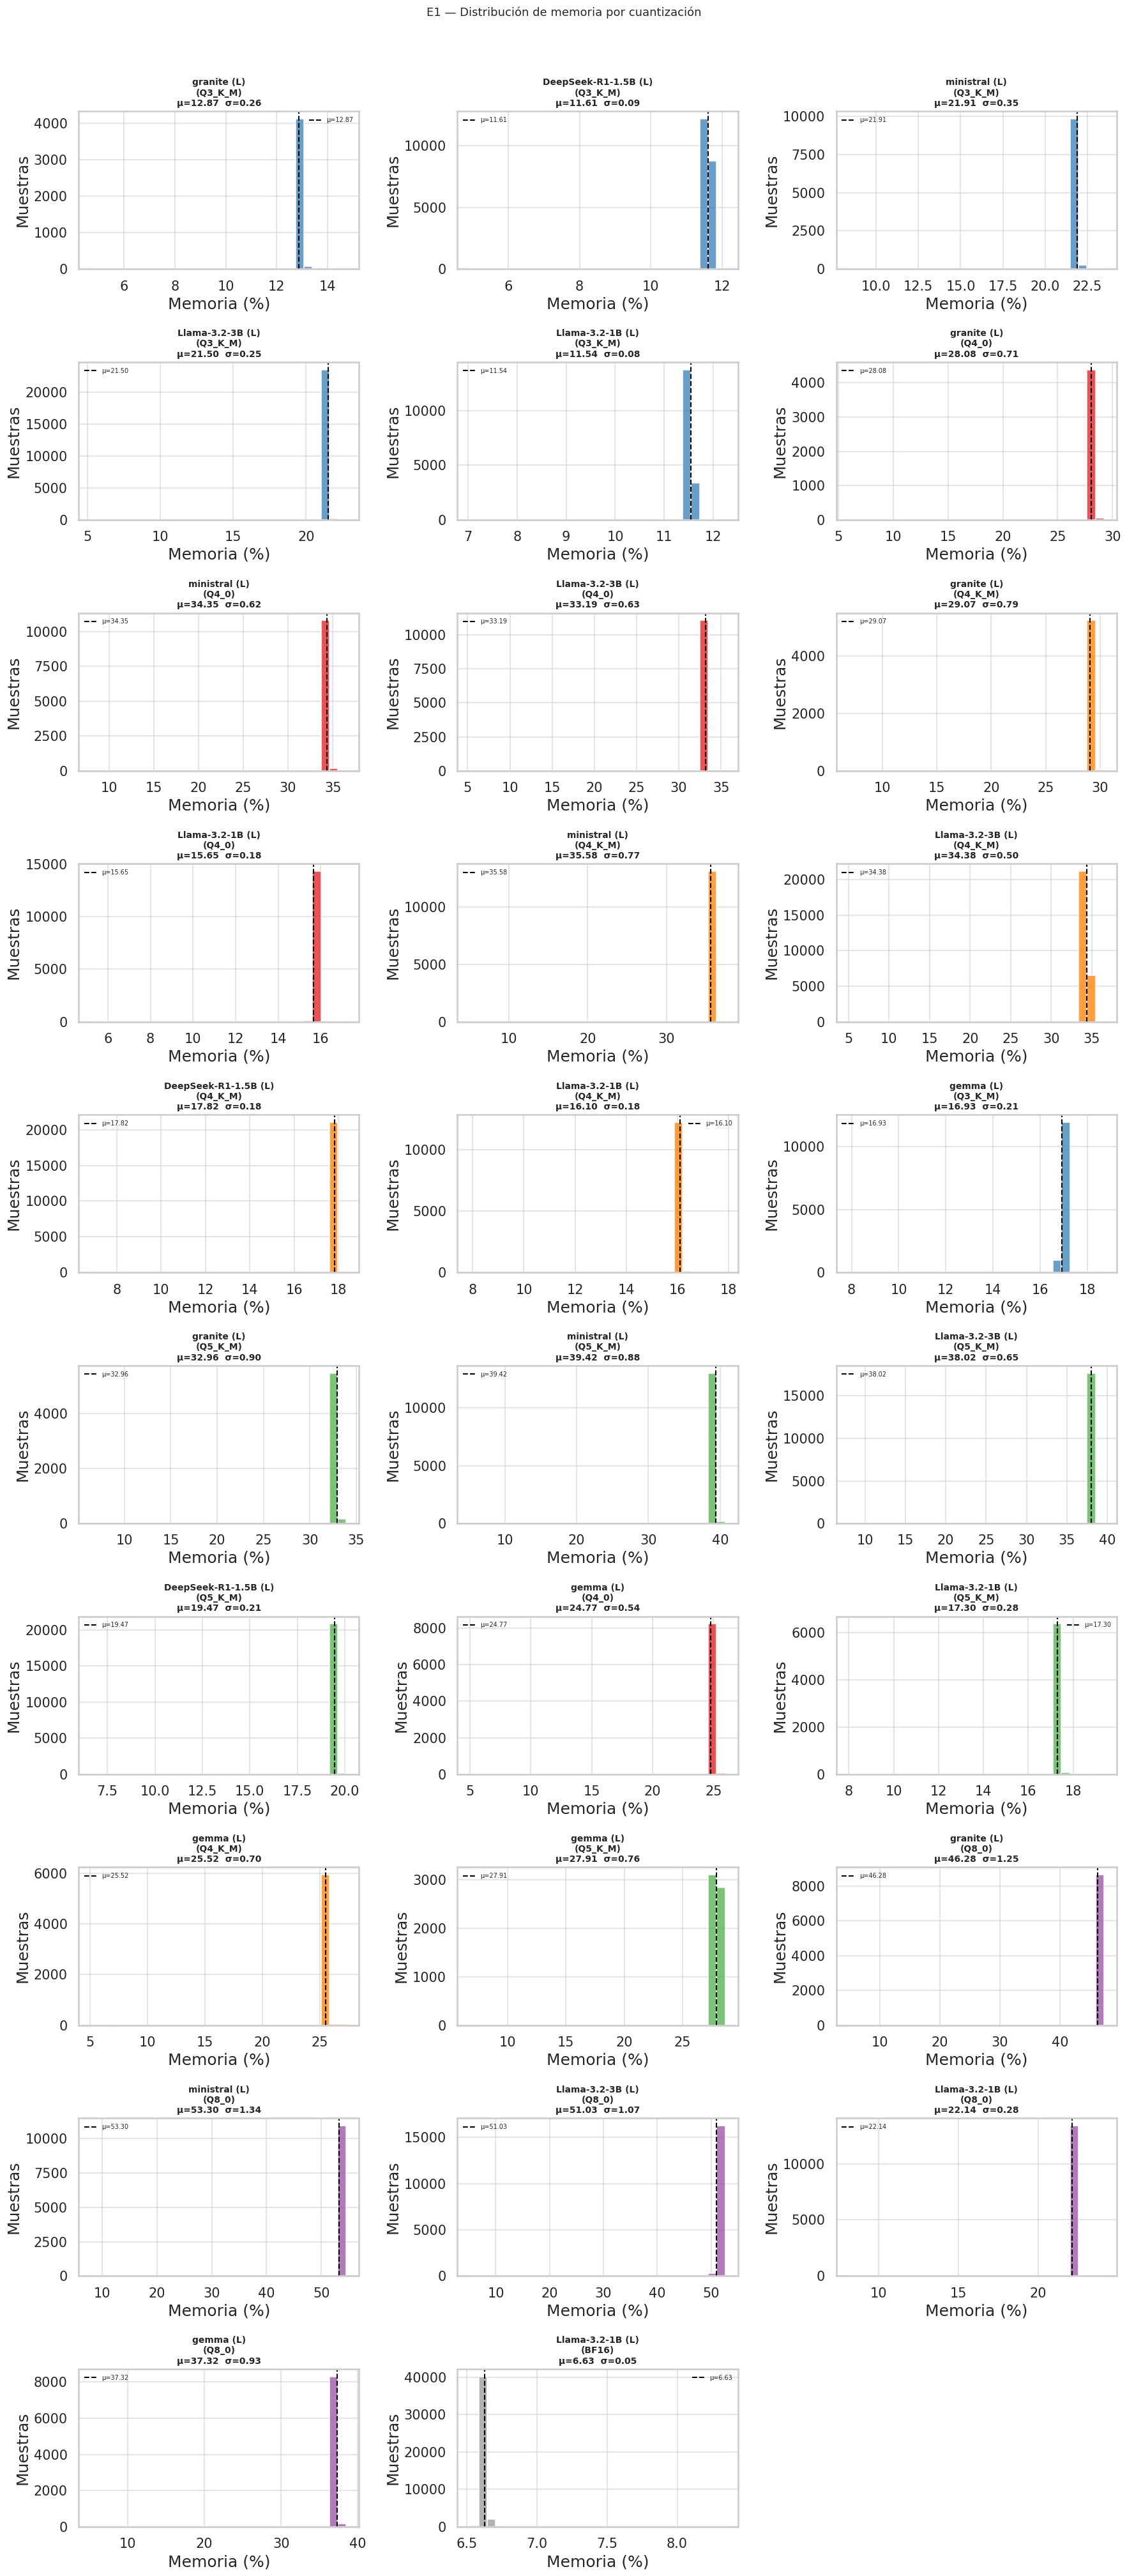

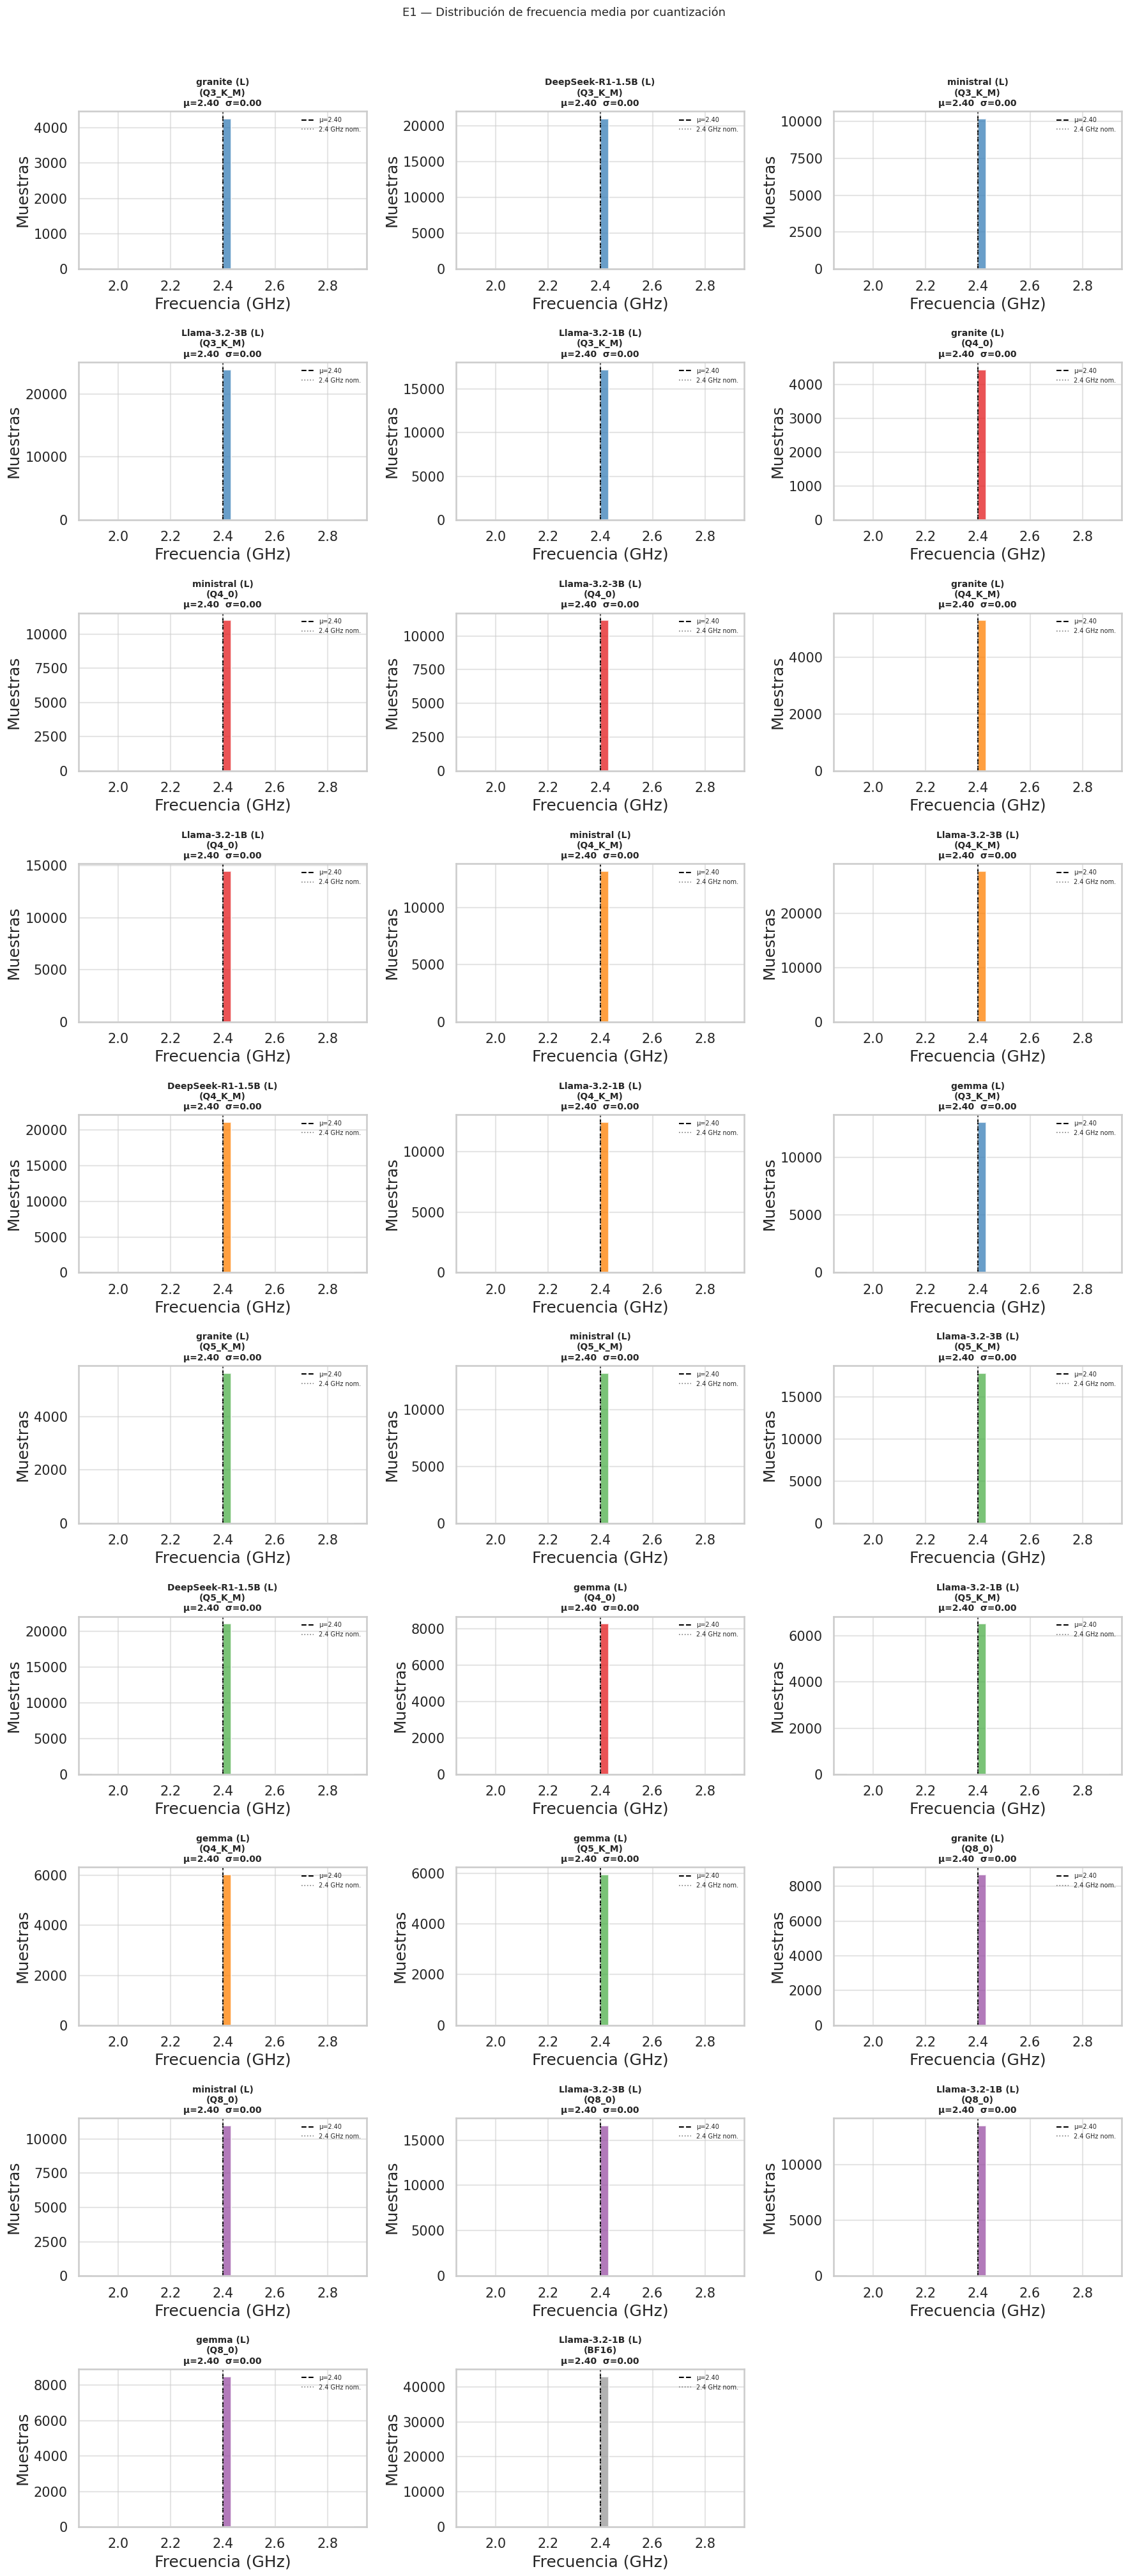

In [5]:
# Distribución de CPU, Memoria y Frecuencia — small multiples por cuantización
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)].copy() if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    hw_ex["quant_label"] = hw_ex["run_id"].map(_ql_map)
    _q_col_d  = "quantization" if "quantization" in ex.columns else "model_short"
    _rid_to_q = ex.set_index("run_id")[_q_col_d].to_dict()
    hw_ex["quantization"] = hw_ex["run_id"].map(_rid_to_q)

    # Orden por BPW ascendente (si disponible)
    if "bits_per_weight" in ex.columns:
        _bpw_map  = ex.set_index("quant_label")["bits_per_weight"].to_dict()
        _order_d  = sorted(
            hw_ex["quant_label"].dropna().unique(),
            key=lambda q: _bpw_map.get(q, 99),
        )
    else:
        _order_d = sorted(hw_ex["quant_label"].dropna().unique())

    # quant_label → color de cuantización
    _ql_color_d = {
        row["quant_label"]: QUANT_COLORS.get(str(row.get(_q_col_d, "")), "tab:gray")
        for _, row in ex.iterrows()
        if pd.notna(row.get("quant_label"))
    }

    def _hist_by_quant(hw_data, col, xlabel, suptitle,
                       xlim=None, vline=None, vline_label=None, cpu_filter=False):
        if col not in hw_data.columns:
            print(f"{col} no disponible"); return
        quants = [q for q in _order_d if q in hw_data["quant_label"].values]
        ncols  = 3
        nrows  = -(-len(quants) // ncols)
        fig, axes = plt.subplots(nrows, ncols,
                                 figsize=(6 * ncols, 4 * nrows),
                                 sharey=False)
        axes_flat = axes.flatten() if nrows * ncols > 1 else [axes]
        for i, ql in enumerate(quants):
            ax   = axes_flat[i]
            data = hw_data[hw_data["quant_label"] == ql][col].dropna()
            if cpu_filter:
                data = data[data > 10]
            if data.empty:
                ax.set_visible(False); continue
            hist_range = xlim if xlim else (data.min(), data.max())
            if hist_range[0] == hist_range[1]:
                hist_range = (hist_range[0] - 0.5, hist_range[1] + 0.5)
            color = _ql_color_d.get(ql, "tab:gray")
            ax.hist(data, bins=30, color=color, alpha=0.75, edgecolor="white",
                    range=hist_range)
            ax.axvline(data.mean(), color="black", ls="--", lw=1.5,
                       label=f"μ={data.mean():.2f}")
            if vline is not None:
                ax.axvline(vline, color="gray", ls=":", lw=1.2,
                           label=vline_label or str(vline))
            ax.legend(fontsize=7)
            if xlim:
                ax.set_xlim(*xlim)
            ax.set_title(
                f"{ql}\nμ={data.mean():.2f}  σ={data.std():.2f}",
                fontsize=10,
            )
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Muestras")
        for j in range(len(quants), len(axes_flat)):
            axes_flat[j].set_visible(False)
        fig.suptitle(suptitle, fontsize=13, y=1.01)
        fig.tight_layout()
        plt.show()

    _hist_by_quant(hw_ex, "cpu_usage_pct", "CPU (%)",
                   "E1 — Distribución CPU por cuantización (muestras con CPU > 10%)",
                   cpu_filter=True)
    _hist_by_quant(hw_ex, "mem_pct", "Memoria (%)",
                   "E1 — Distribución de memoria por cuantización")
    _hist_by_quant(hw_ex, "freq_mean_ghz", "Frecuencia (GHz)",
                   "E1 — Distribución de frecuencia media por cuantización",
                   vline=2.4, vline_label="2.4 GHz nom.")
else:
    print("Sin datos de hardware para distribuciones CPU/Memoria/Frecuencia")


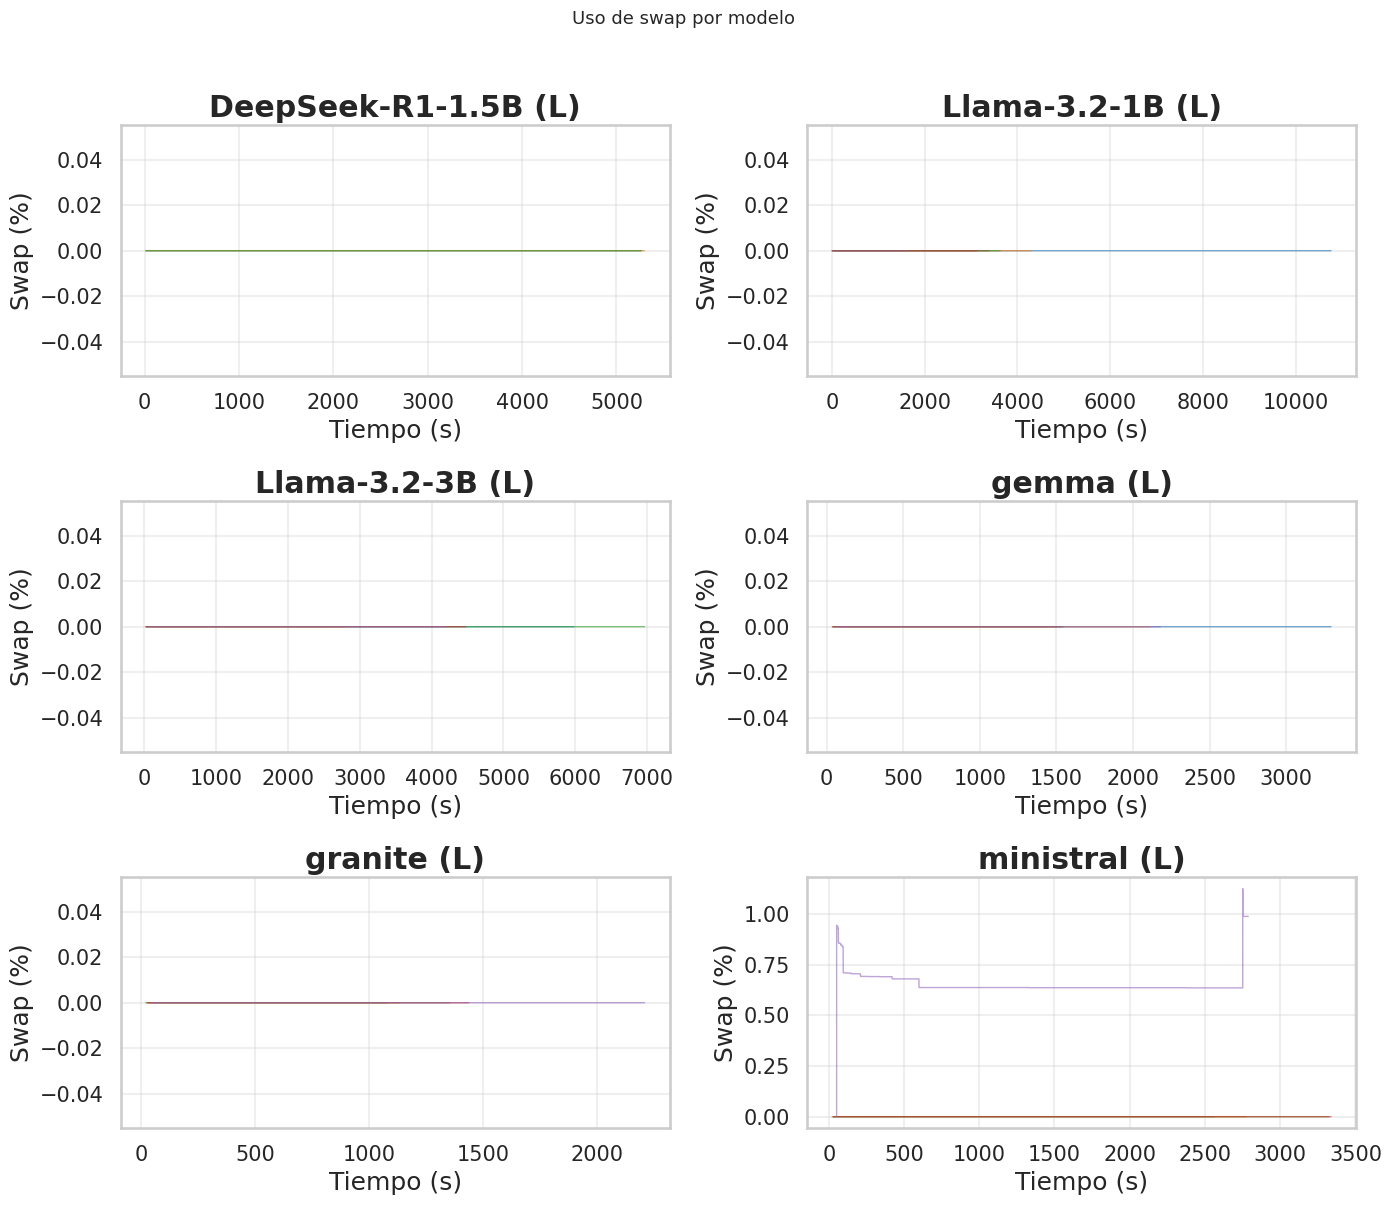

In [6]:
# Swap por modelo (small multiples)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty:
    models = sorted(ex["model_label"].unique())
    ncols = 2
    nrows = (len(models) + 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    for ax, model in zip(axes, models):
        hw_m = hw_ex[hw_ex["model_label"] == model]
        if hw_m.empty:
            ax.text(0.5, 0.5, f"{model}\nSin datos", ha="center", va="center",
                    transform=ax.transAxes)
            ax.set_axis_off()
            continue
        for rid in hw_m["run_id"].unique():
            sub = hw_m[hw_m["run_id"] == rid].sort_values("t_rel_s")
            ax.plot(sub["t_rel_s"].values, sub["swap_pct"].values, alpha=0.6, linewidth=1)
        ax.set_xlabel("Tiempo (s)")
        ax.set_ylabel("Swap (%)")
        ax.set_title(model, fontweight="bold")
        ax.grid(True, alpha=0.3)
    for ax in axes[len(models):]:
        ax.set_visible(False)
    fig.suptitle("Uso de swap por modelo", fontsize=13, y=1.01)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos de hardware para swap")

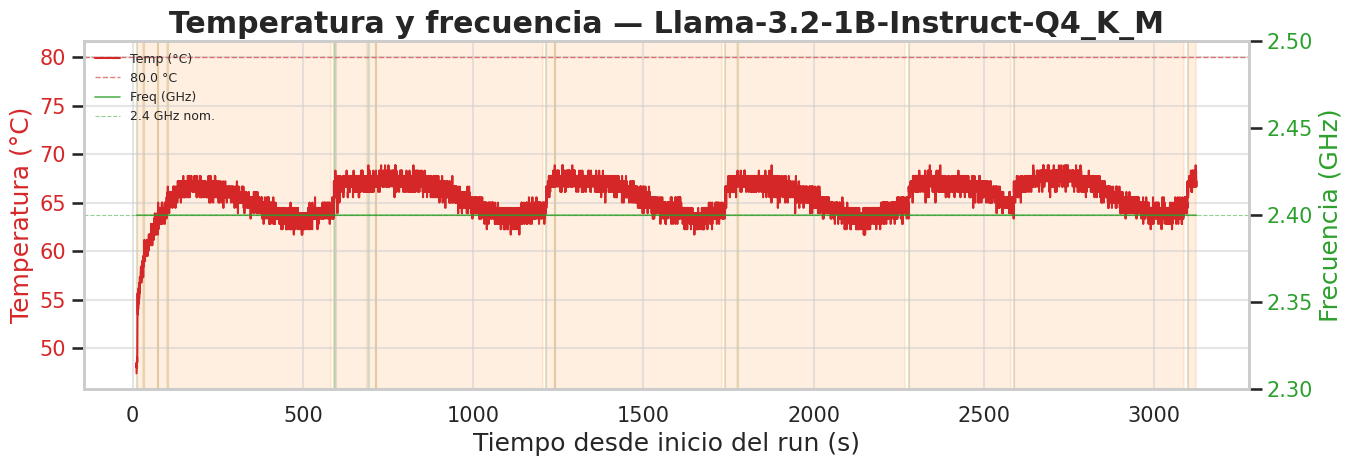

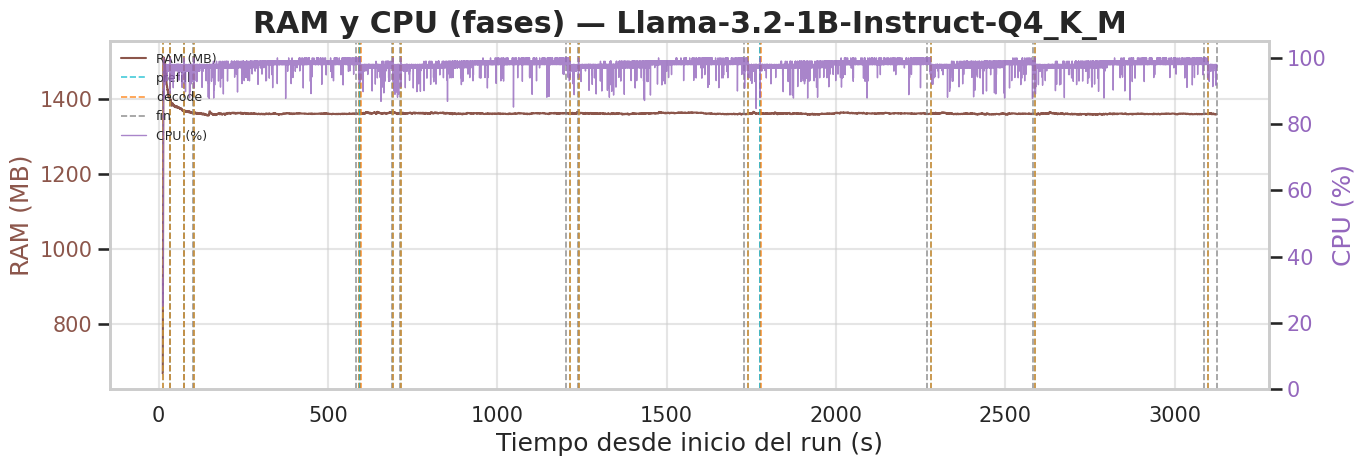

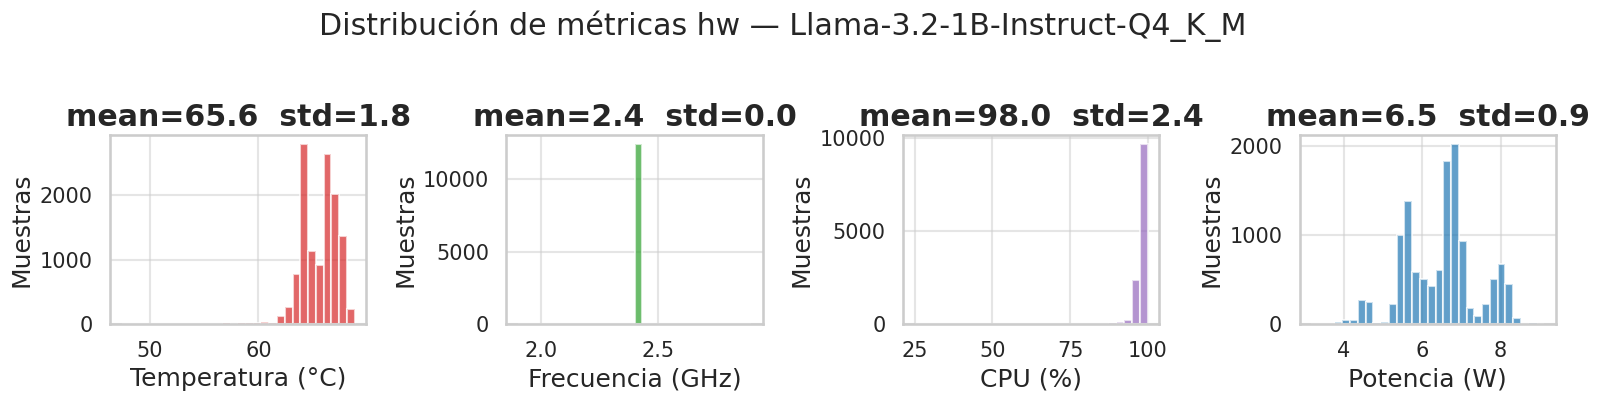

In [7]:
# Análisis detallado de un run representativo (mediana de duración)
from monitorviz.viz import temp_freq_dual, cpu_memory_dual_phases, hw_distributions_panel

_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

if not hw_ex.empty and len(ex) > 0:
    run_durations = hw_ex.groupby("run_id")["t_rel_s"].max().sort_values()
    median_idx = len(run_durations) // 2
    representative_run_id = run_durations.index[median_idx]
    representative_run = next((r for r in coll.runs if r.run_id == representative_run_id), None)
    if representative_run:
        hw_r = hw_ex[hw_ex["run_id"] == representative_run_id]
        try:
            fig = temp_freq_dual(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"temp_freq_dual: {e}")
        try:
            fig = cpu_memory_dual_phases(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"cpu_memory_dual_phases: {e}")
        try:
            fig = hw_distributions_panel(hw_r, representative_run)
            plt.show()
        except Exception as e:
            print(f"hw_distributions_panel: {e}")
    else:
        print("No se encontro run representativo")
else:
    print("Sin datos para análisis detallado")

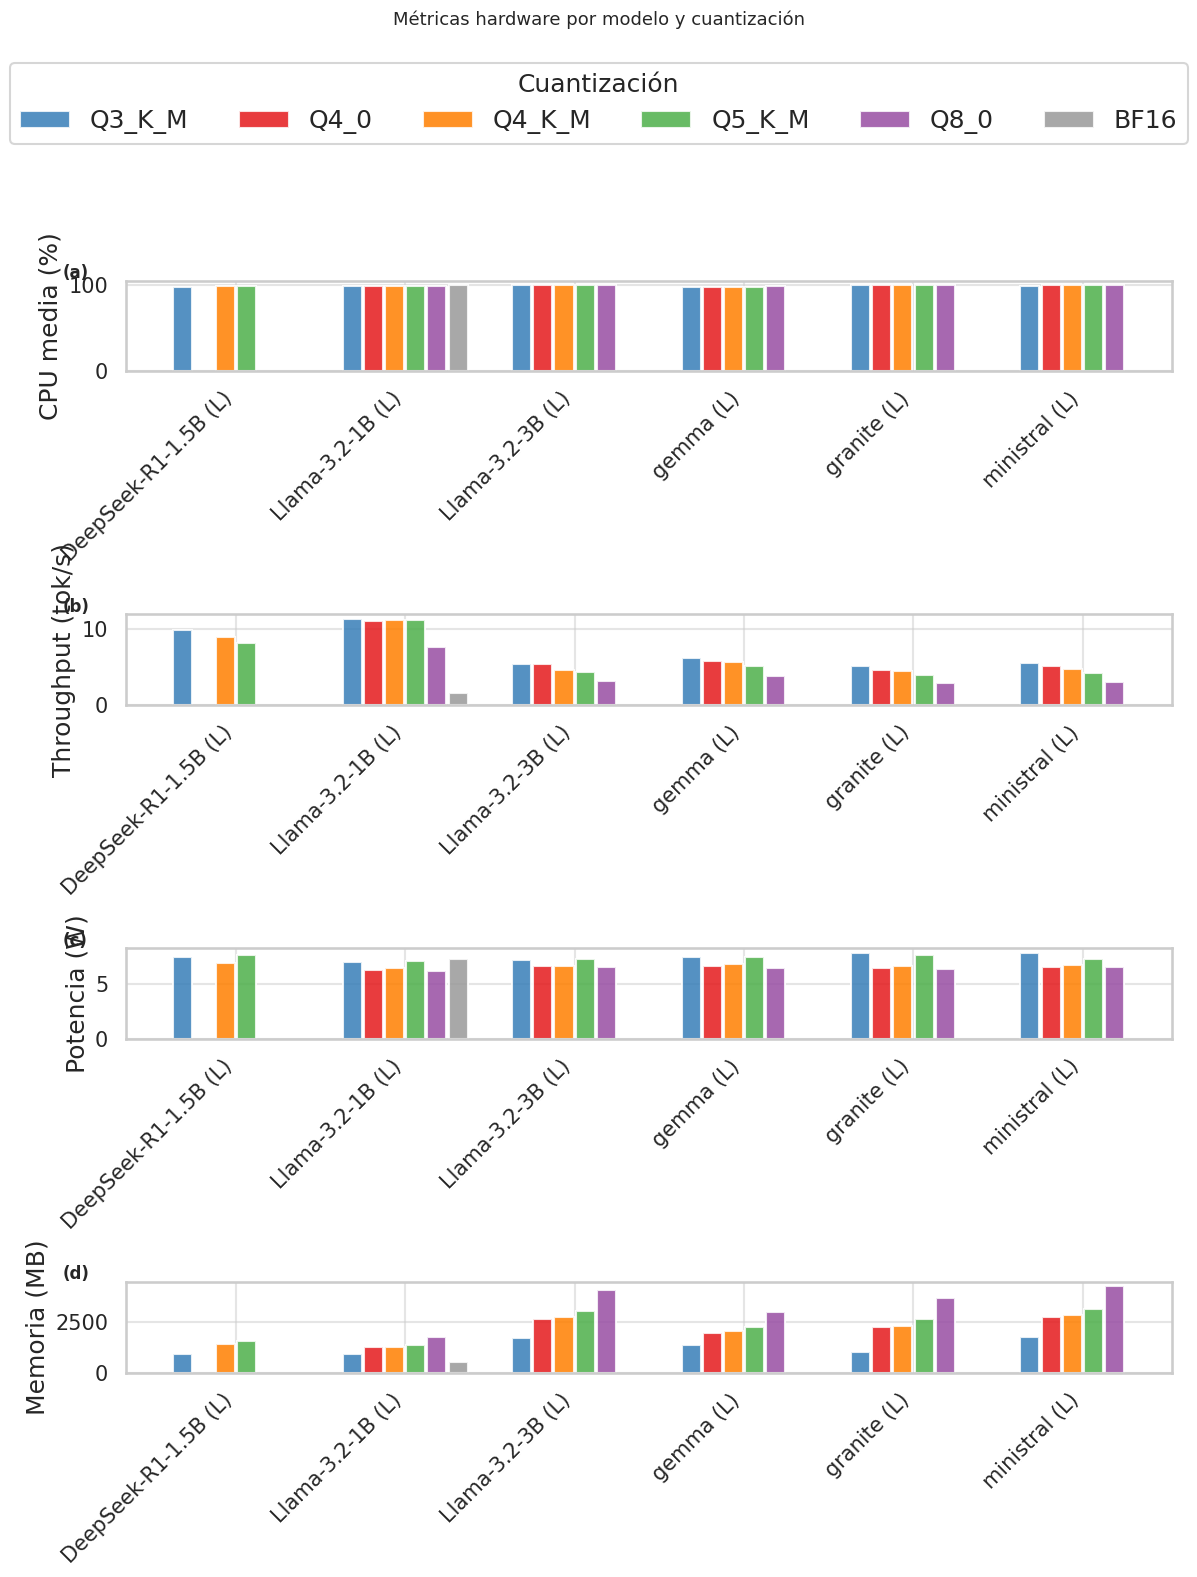

In [8]:
# Grouped bar chart hardware (4 paneles)
_run_ids = ex["run_id"].tolist() if "run_id" in ex.columns else []
hw_ex = hw_full[hw_full["run_id"].isin(_run_ids)] if "run_id" in hw_full.columns else pd.DataFrame()

hw_summary_rows = []
pm_valid_tmp = (pm_full[
                    (pm_full["run_id"].isin(_run_ids)) &
                    (~pm_full["is_empty_generation"]) &
                    (pm_full["latency_ms"] > 0)
                    ] if "run_id" in pm_full.columns else pd.DataFrame())

_q_col_gb = "quantization" if "quantization" in ex.columns else "model_short"

for _, row in ex.iterrows():
    if "run_id" not in row.index:
        continue

    hw_r = hw_ex[hw_ex["run_id"] == row["run_id"]] if "run_id" in hw_ex.columns else pd.DataFrame()
    pm_r = pm_valid_tmp[pm_valid_tmp["run_id"] == row["run_id"]] if "run_id" in pm_valid_tmp.columns else pd.DataFrame()

    if hw_r.empty:
        continue

    active_r = hw_r[hw_r["cpu_usage_pct"] > 50]
    quant_name = str(row.get(_q_col_gb, "?"))

    hw_summary_rows.append({
        "model": row["model_label"],
        "config": quant_name,
        "cpu_pct": active_r["cpu_usage_pct"].mean() if not active_r.empty else float("nan"),
        "tokens_s": pm_r["tokens_per_second"].mean() if not pm_r.empty else float("nan"),
        "power_w": hw_r["internal_power_w"].mean(),
        "mem_mb": hw_r["mem_used_bytes"].mean() / (1024 ** 2) if not hw_r.empty else float("nan"),
    })

if hw_summary_rows:
    hw_summary = pd.DataFrame(hw_summary_rows)

    METRICS_GB = [
        ("cpu_pct", "CPU media (%)", "(a)"),
        ("tokens_s", "Throughput (tok/s)", "(b)"),
        ("power_w", "Potencia (W)", "(c)"),
        ("mem_mb", "Memoria (MB)", "(d)"),
    ]

    models_gb = sorted(hw_summary["model"].unique())

    configs_gb = [q for q in QUANT_ORDER if q in hw_summary["config"].unique()]
    configs_gb += [q for q in hw_summary["config"].unique() if q not in QUANT_ORDER]

    x_pos = np.arange(len(models_gb))
    n_cfg = len(configs_gb)
    width = 0.75 / max(n_cfg, 1)

    fig, axes = plt.subplots(
        len(METRICS_GB),
        1,
        figsize=(12, 4 * len(METRICS_GB))
    )

    for i, (ax, (col, ylabel, label)) in enumerate(zip(axes, METRICS_GB)):
        data = hw_summary.dropna(subset=[col])

        for j, cfg in enumerate(configs_gb):
            color = QUANT_COLORS.get(cfg, f"C{j}")

            vals = [
                data[
                    (data["model"] == m) &
                    (data["config"] == cfg)
                    ][col].mean()
                for m in models_gb
            ]

            offset = (j - n_cfg / 2 + 0.5) * width

            ax.bar(
                x_pos + offset,
                vals,
                width * 0.9,
                label=cfg,
                color=color,
                alpha=0.85
            )

        ax.set_xticks(x_pos)
        ax.set_xticklabels(models_gb, rotation=45, ha="right")
        ax.set_ylabel(ylabel)

        ax.text(
            -0.06,
            1.03,
            label,
            transform=ax.transAxes,
            fontweight="bold",
            fontsize=12
        )

    # Obtener handles de la leyenda
    handles, labels = axes[0].get_legend_handles_labels()

    # Título general
    fig.suptitle(
        "Métricas hardware por modelo y cuantización",
        fontsize=13,
        y=0.99
    )

    # Leyenda global debajo del título
    fig.legend(
        handles,
        labels,
        title="Cuantización",
        loc="upper center",
        bbox_to_anchor=(0.5, 0.965),
        ncol=min(len(configs_gb), 6),
        frameon=True
    )

    # Reservar espacio arriba para título y leyenda
    fig.tight_layout(rect=[0, 0, 1, 0.88])

    plt.show()

else:
    print("Sin datos para grouped bar chart hardware")

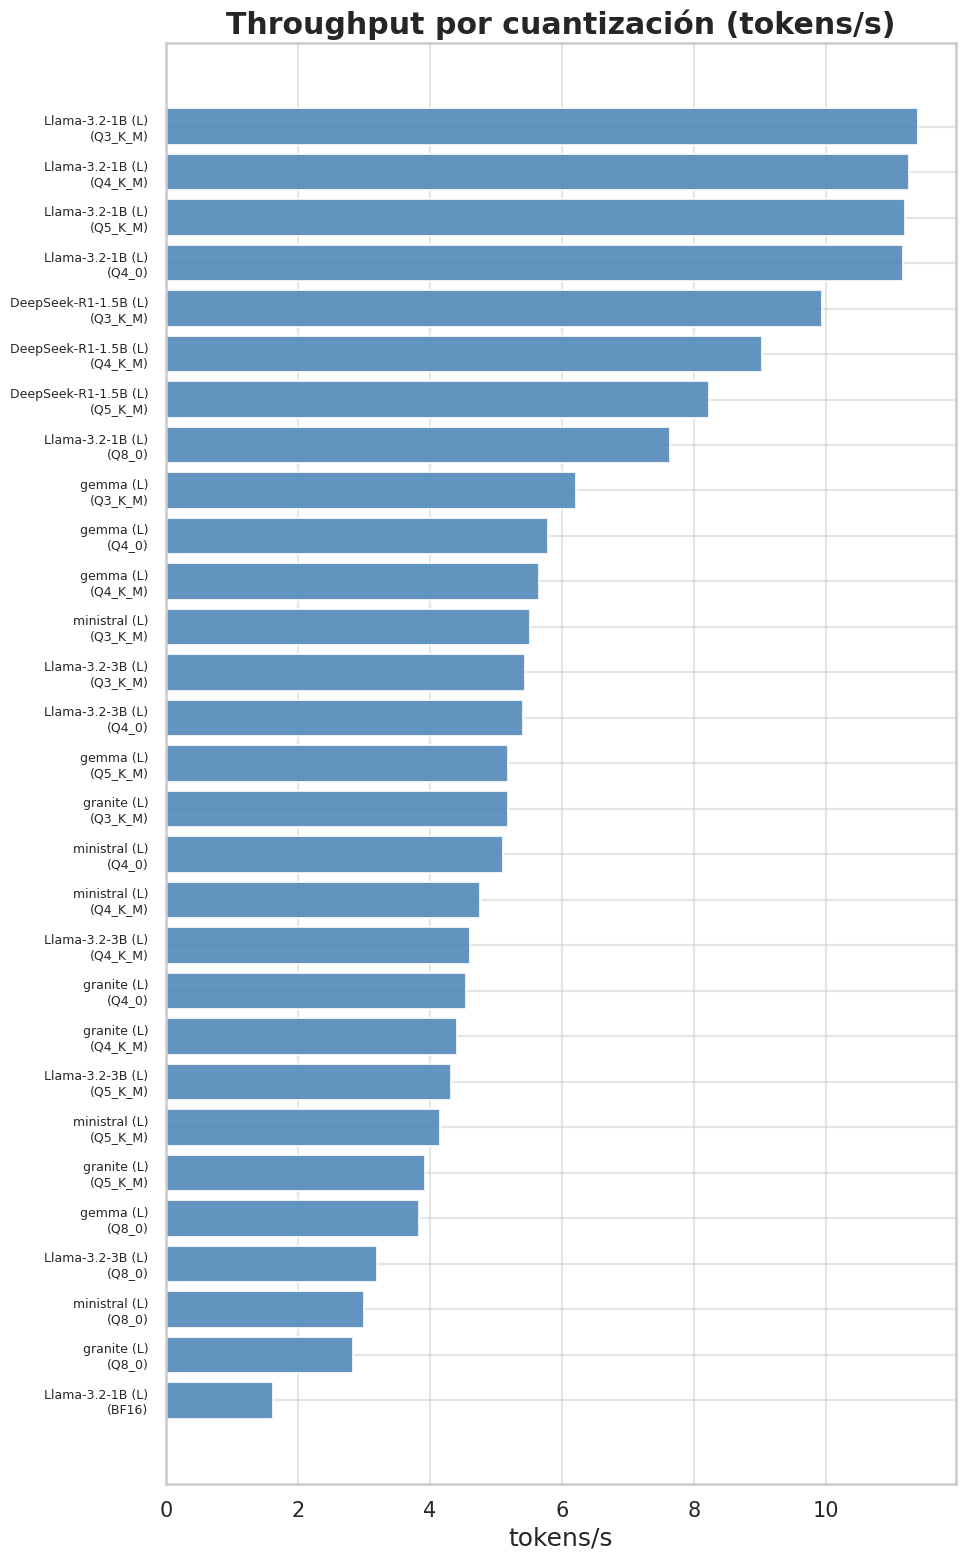

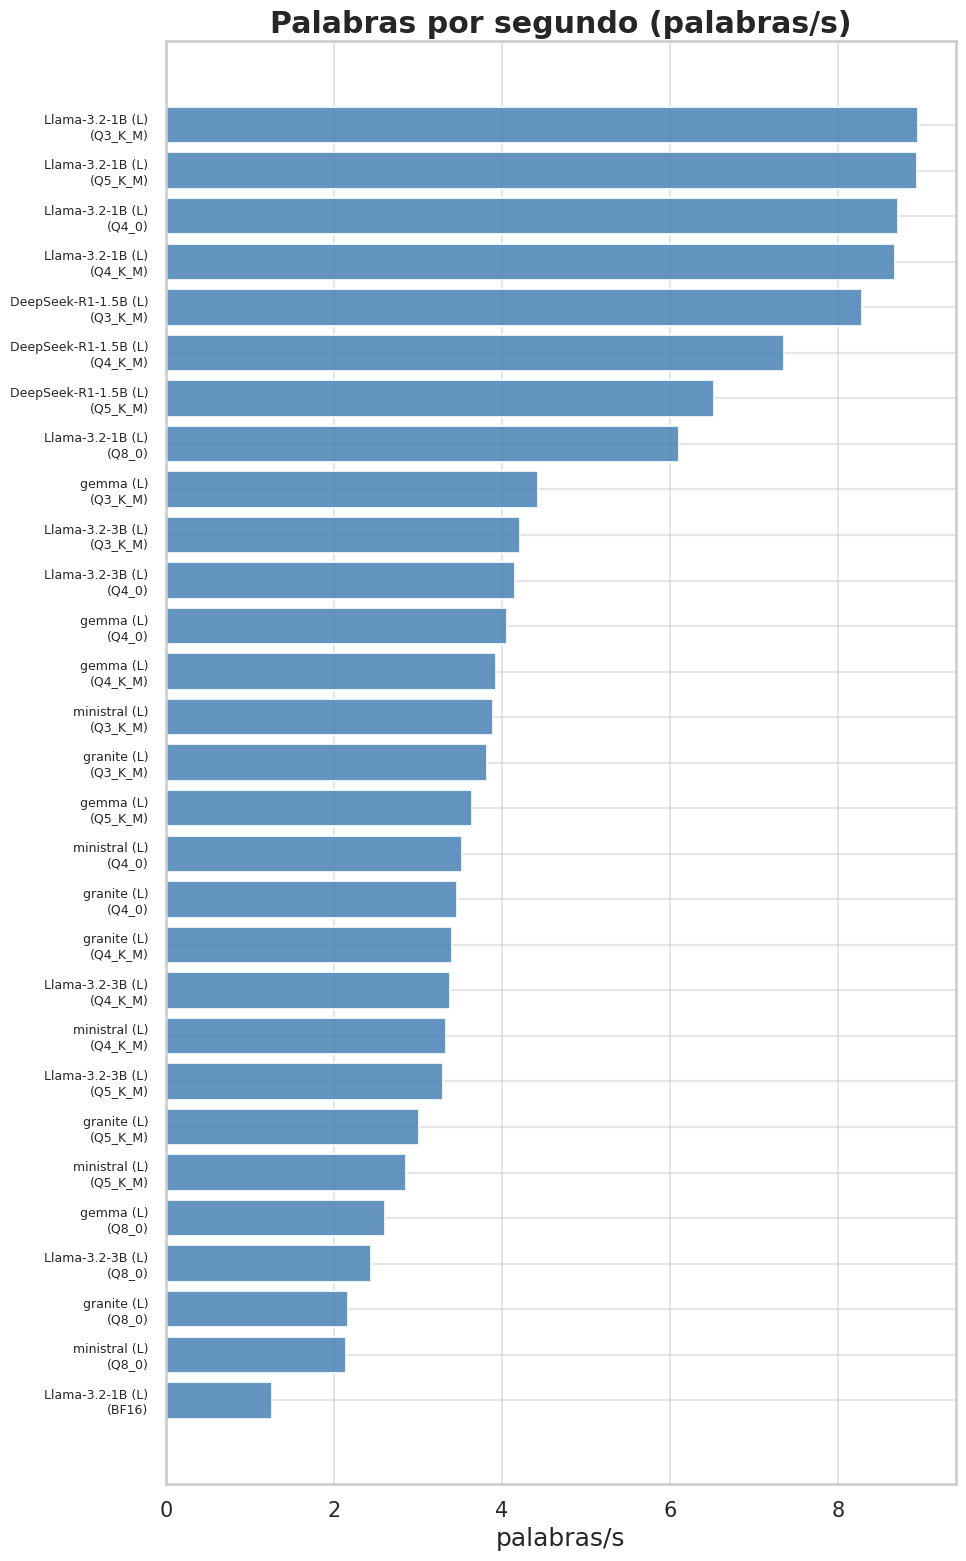

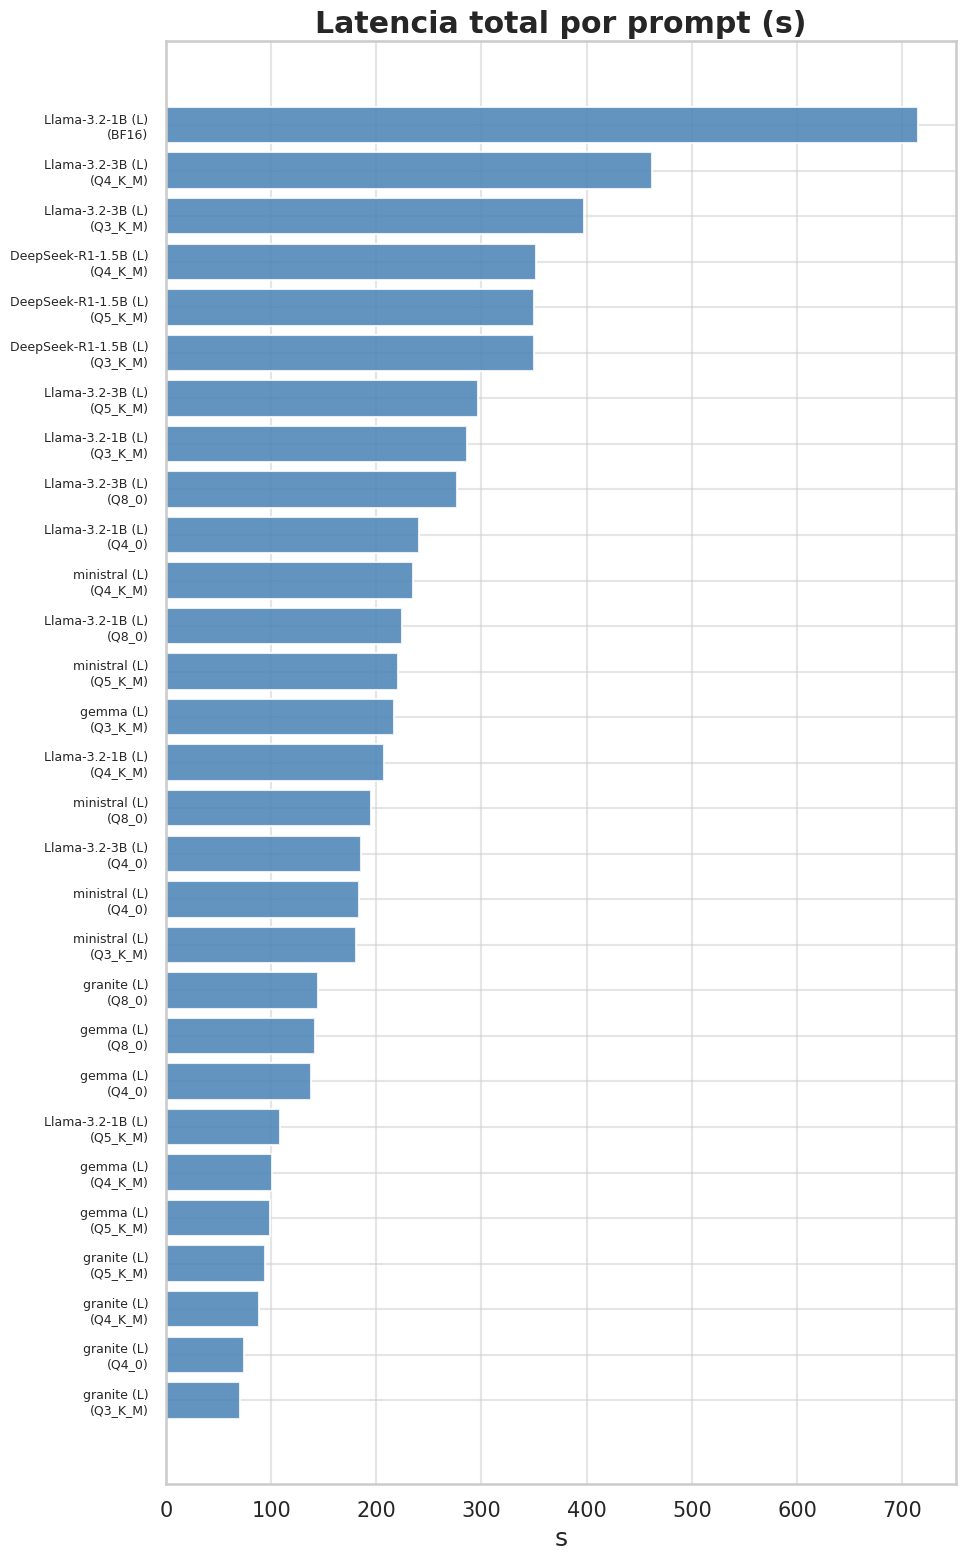

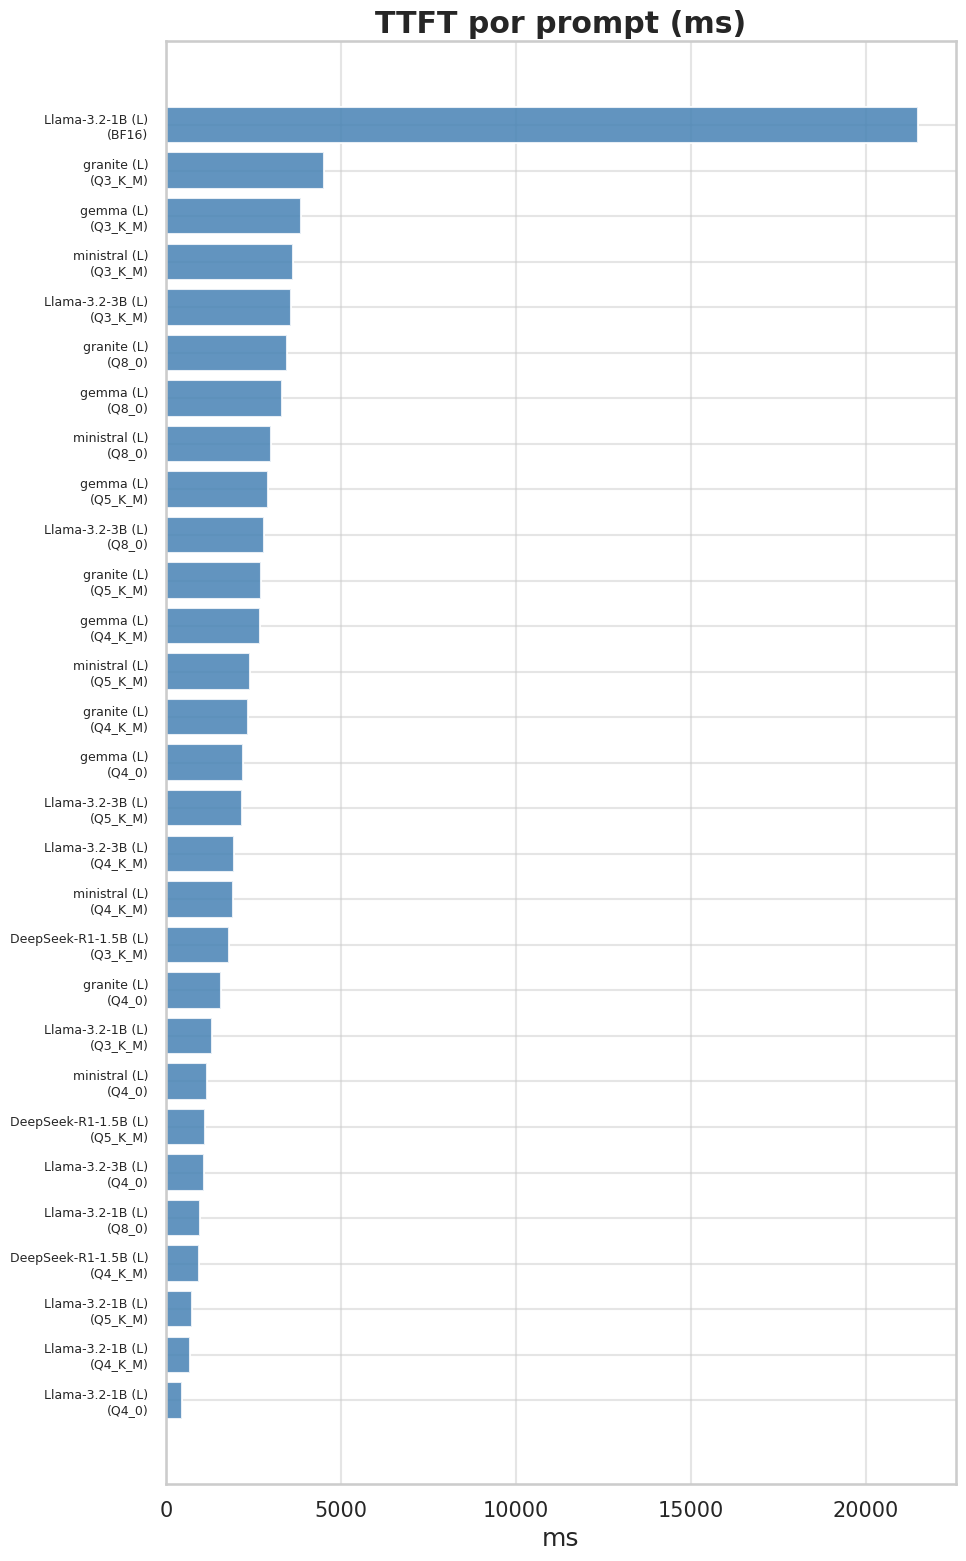

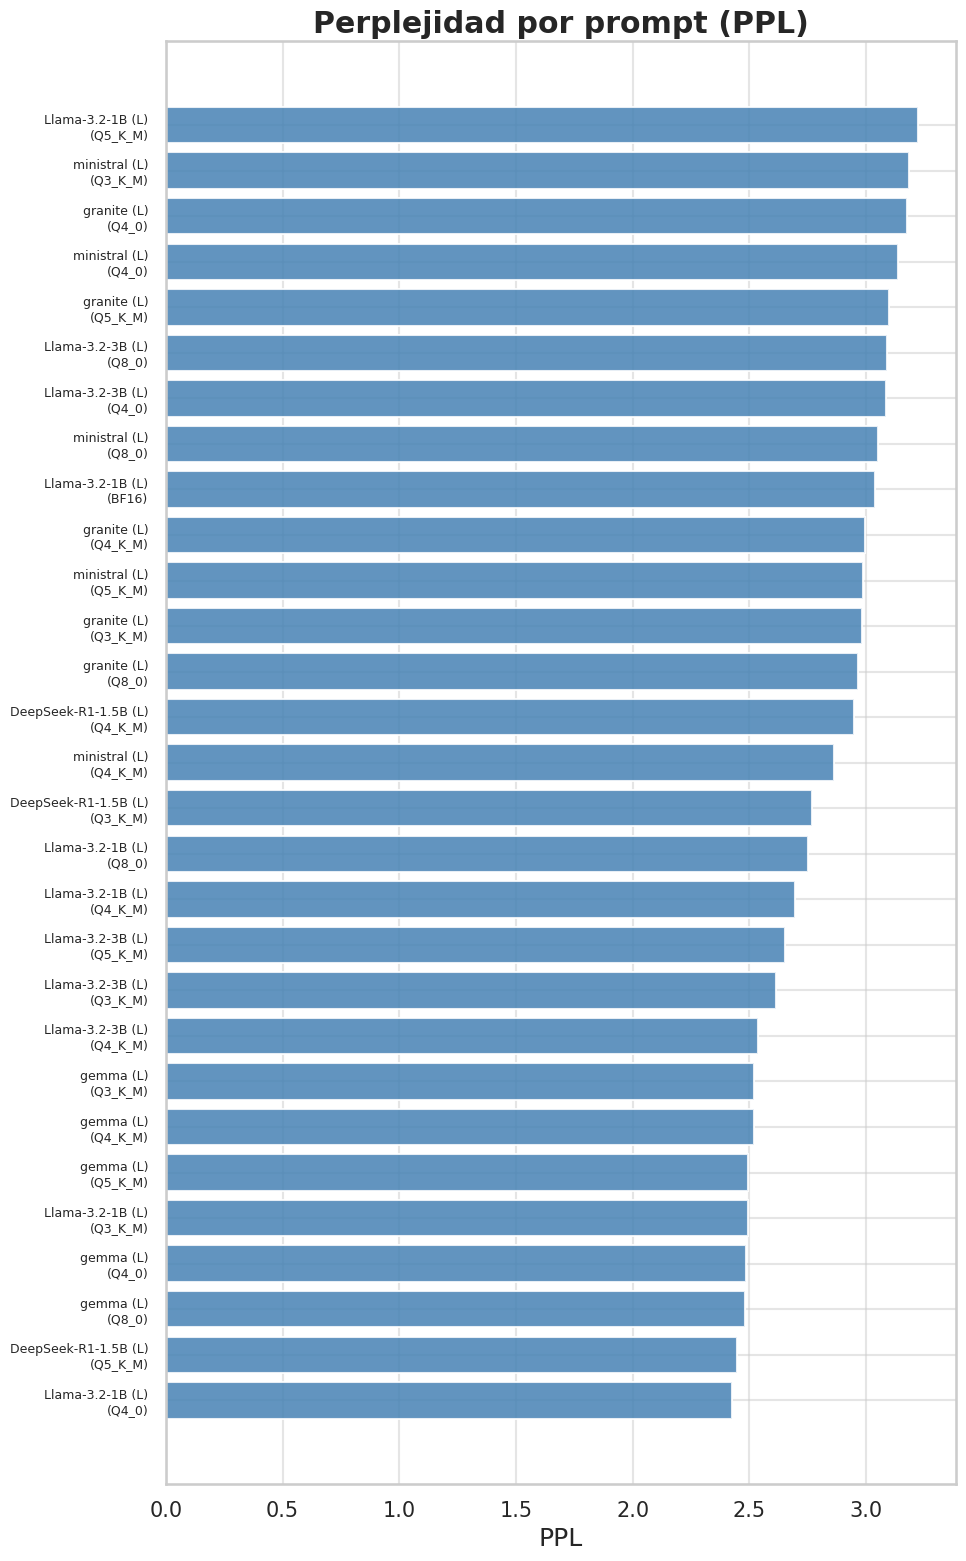

In [9]:
# Métricas de inferencia por cuantización
def _plot_metric_e1(df, metric, ylabel, title, unit_divisor=1.0, unit_label=""):
    data = df.dropna(subset=[metric]).copy()
    if "quant_label" not in data.columns:
        data["quant_label"] = data["run_id"].map(_ql_map)
    data["_val"] = data[metric] / unit_divisor
    order = (data.groupby("quant_label")["_val"].mean()
             .sort_values().index.tolist())
    means = data.groupby("quant_label")["_val"].mean().reindex(order)
    fig, ax = plt.subplots(figsize=(10, max(4, len(order) * 0.55)))
    ax.barh(range(len(order)), means.values, alpha=0.85, color="steelblue")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(unit_label or metric)
    ax.set_title(f"{title}" + (f" ({unit_label})" if unit_label else ""))
    fig.tight_layout()
    plt.show()

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    pm_valid["quant_label"] = pm_valid["run_id"].map(_ql_map)
    _plot_metric_e1(pm_valid, "tokens_per_second", "tokens/s",
                    "Throughput por cuantización", unit_label="tokens/s")
    _plot_metric_e1(pm_valid, "words_per_second", "palabras/s",
                    "Palabras por segundo", unit_label="palabras/s")
    _plot_metric_e1(pm_valid, "latency_ms", "s", "Latencia total por prompt",
                    unit_divisor=1000, unit_label="s")
    _plot_metric_e1(pm_valid, "time_to_first_token_ms", "ms",
                    "TTFT por prompt", unit_label="ms")
    ppl_valid = pm_valid.dropna(subset=["perplexity"])
    if not ppl_valid.empty:
        _plot_metric_e1(ppl_valid, "perplexity", "", "Perplejidad por prompt",
                        unit_label="PPL")
else:
    print("Sin datos de inferencia")


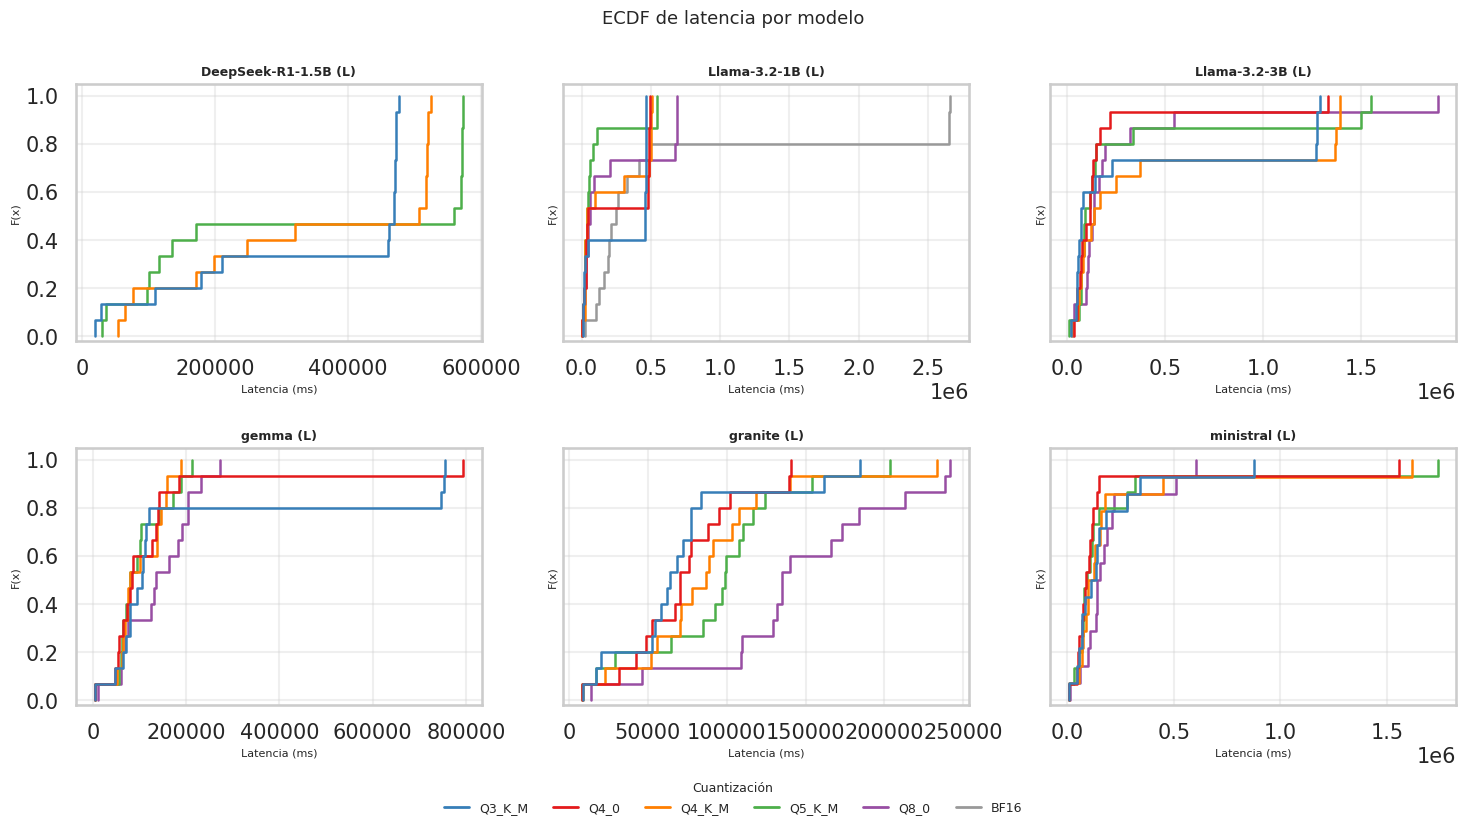

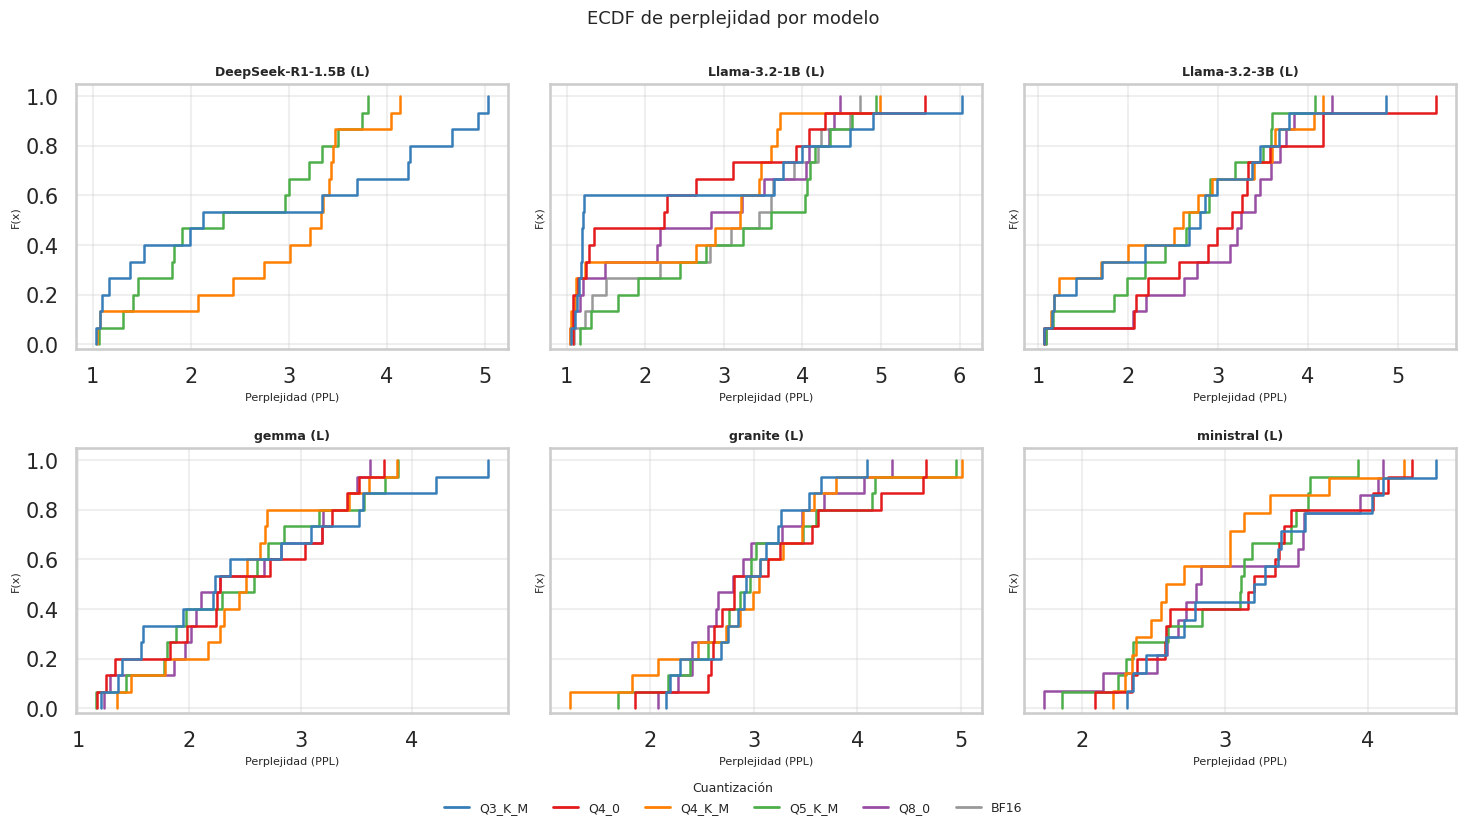

In [10]:
# ECDFs de latencia y perplejidad — un panel por modelo, líneas por cuantización
from matplotlib.lines import Line2D as _L2D

_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if pm_valid.empty:
    print("Sin datos para ECDFs")
else:
    # Añadir solo las columnas que faltan en pm_valid (model_label ya viene de pm_full)
    _cols_to_add = [c for c in ["model_label", "quantization"] if c not in pm_valid.columns]
    if _cols_to_add:
        _run_meta = ex[["run_id"] + _cols_to_add].copy()
        pm_valid = pm_valid.merge(_run_meta, on="run_id", how="left")

    _models_ecdf = sorted(pm_valid["model_label"].dropna().unique())
    _ncols = 3
    _nrows = (len(_models_ecdf) + _ncols - 1) // _ncols

    def _ecdf_by_model(pm_df, metric, xlabel, title):
        fig, axes = plt.subplots(
            _nrows, _ncols,
            figsize=(5 * _ncols, 4 * _nrows),
            sharey=True,
        )
        axes = np.array(axes).flatten()

        quants_in_fig = [q for q in QUANT_ORDER if q in pm_df["quantization"].values]

        for ax, model in zip(axes, _models_ecdf):
            sub = pm_df[pm_df["model_label"] == model].dropna(subset=[metric])
            ax.set_title(model, fontweight="bold", fontsize=9)
            ax.set_xlabel(xlabel, fontsize=8)
            ax.set_ylabel("F(x)", fontsize=8)
            ax.set_ylim(-0.02, 1.05)
            ax.grid(True, alpha=0.3)

            if sub.empty:
                ax.text(0.5, 0.5, "Sin datos", ha="center", va="center",
                        transform=ax.transAxes, color="gray")
                continue

            sns.ecdfplot(
                data=sub,
                x=metric,
                hue="quantization",
                hue_order=quants_in_fig,
                palette=QUANT_COLORS,
                ax=ax,
                linewidth=1.8,
            )
            leg = ax.get_legend()
            if leg:
                leg.remove()

        for ax in axes[len(_models_ecdf):]:
            ax.set_visible(False)

        # Leyenda compartida al pie de la figura
        handles = [
            _L2D([0], [0], color=QUANT_COLORS.get(q, "gray"), lw=2, label=q)
            for q in quants_in_fig
        ]
        fig.legend(
            handles=handles, loc="lower center",
            ncol=len(quants_in_fig), fontsize=9,
            title="Cuantización", title_fontsize=9,
            bbox_to_anchor=(0.5, -0.04),
        )
        fig.suptitle(title, fontsize=13)
        fig.tight_layout()
        plt.show()

    _ecdf_by_model(pm_valid, "latency_ms",  "Latencia (ms)",      "ECDF de latencia por modelo")

    ppl_df = pm_valid.dropna(subset=["perplexity"])
    if not ppl_df.empty:
        _ecdf_by_model(ppl_df, "perplexity", "Perplejidad (PPL)", "ECDF de perplejidad por modelo")


/tmp/ipykernel_363124/1515318731.py:31: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


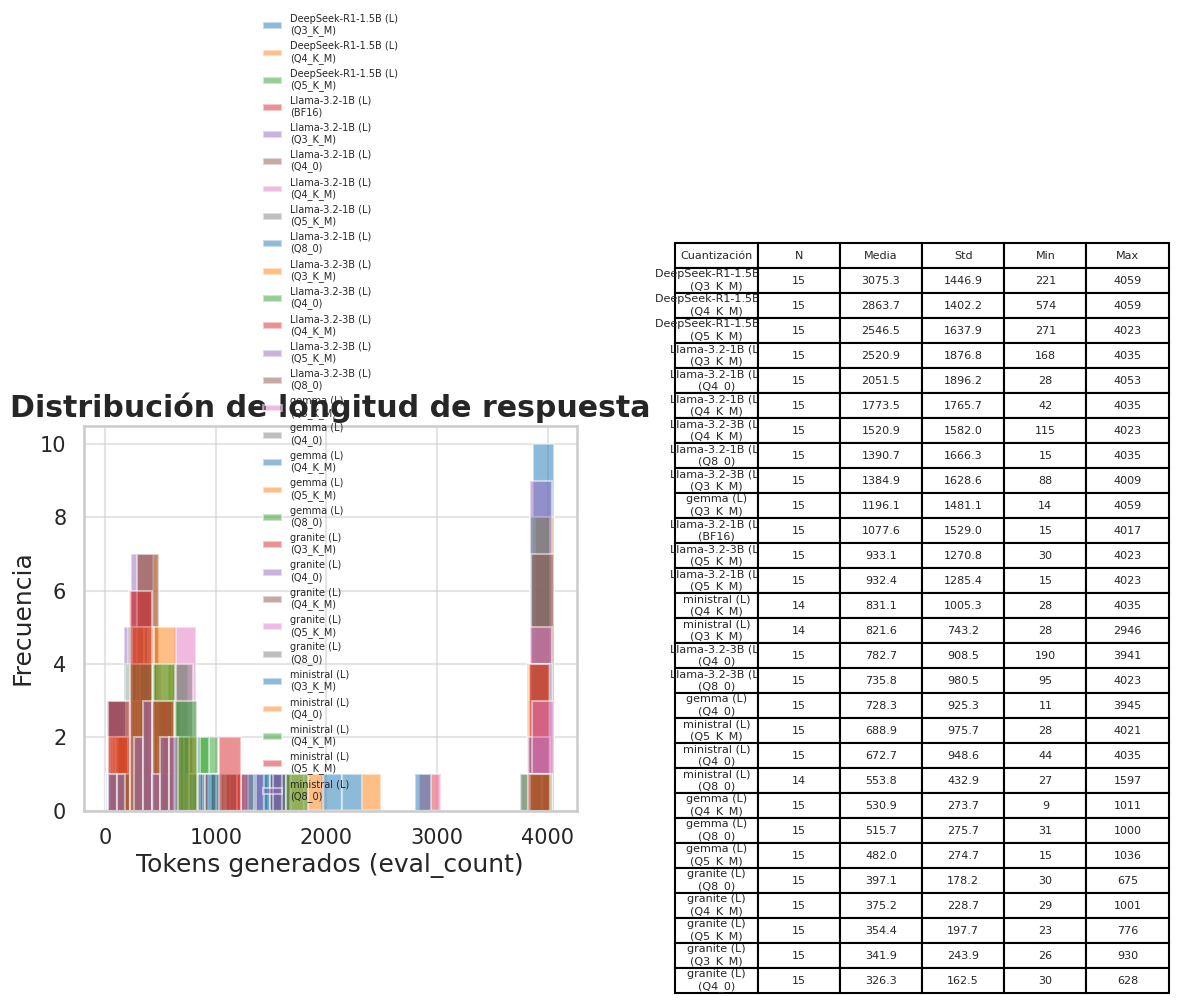

In [11]:
# Distribución de longitud de respuesta
_run_ids_pm = ex["run_id"].tolist() if "run_id" in ex.columns else []
pm_valid = (pm_full[
    (pm_full["run_id"].isin(_run_ids_pm)) &
    (~pm_full["is_empty_generation"]) &
    (pm_full["latency_ms"] > 0)
].copy() if "run_id" in pm_full.columns else pd.DataFrame())

if not pm_valid.empty:
    pm_valid["quant_label"] = pm_valid["run_id"].map(_ql_map)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ql in sorted(pm_valid["quant_label"].unique()):
        sub = pm_valid[pm_valid["quant_label"] == ql]
        axes[0].hist(sub["eval_count"], bins=20, alpha=0.5, label=ql)
    axes[0].set_xlabel("Tokens generados (eval_count)")
    axes[0].set_ylabel("Frecuencia")
    axes[0].set_title("Distribución de longitud de respuesta")
    axes[0].legend(fontsize=7)
    summary_resp = pm_valid.groupby("quant_label")["eval_count"].agg(
        count="count", mean="mean", std="std", min="min", max="max"
    ).round(1).sort_values("mean", ascending=False)
    axes[1].axis("off")
    table_data = [["Cuantización", "N", "Media", "Std", "Min", "Max"]]
    for idx, row in summary_resp.iterrows():
        table_data.append([idx, int(row["count"]), f"{row['mean']:.1f}",
                           f"{row['std']:.1f}", f"{row['min']:.0f}", f"{row['max']:.0f}"])
    t = axes[1].table(cellText=table_data, loc="center", cellLoc="center")
    t.auto_set_font_size(False)
    t.set_fontsize(8)
    t.scale(1, 1.5)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos para distribución de longitud de respuesta")


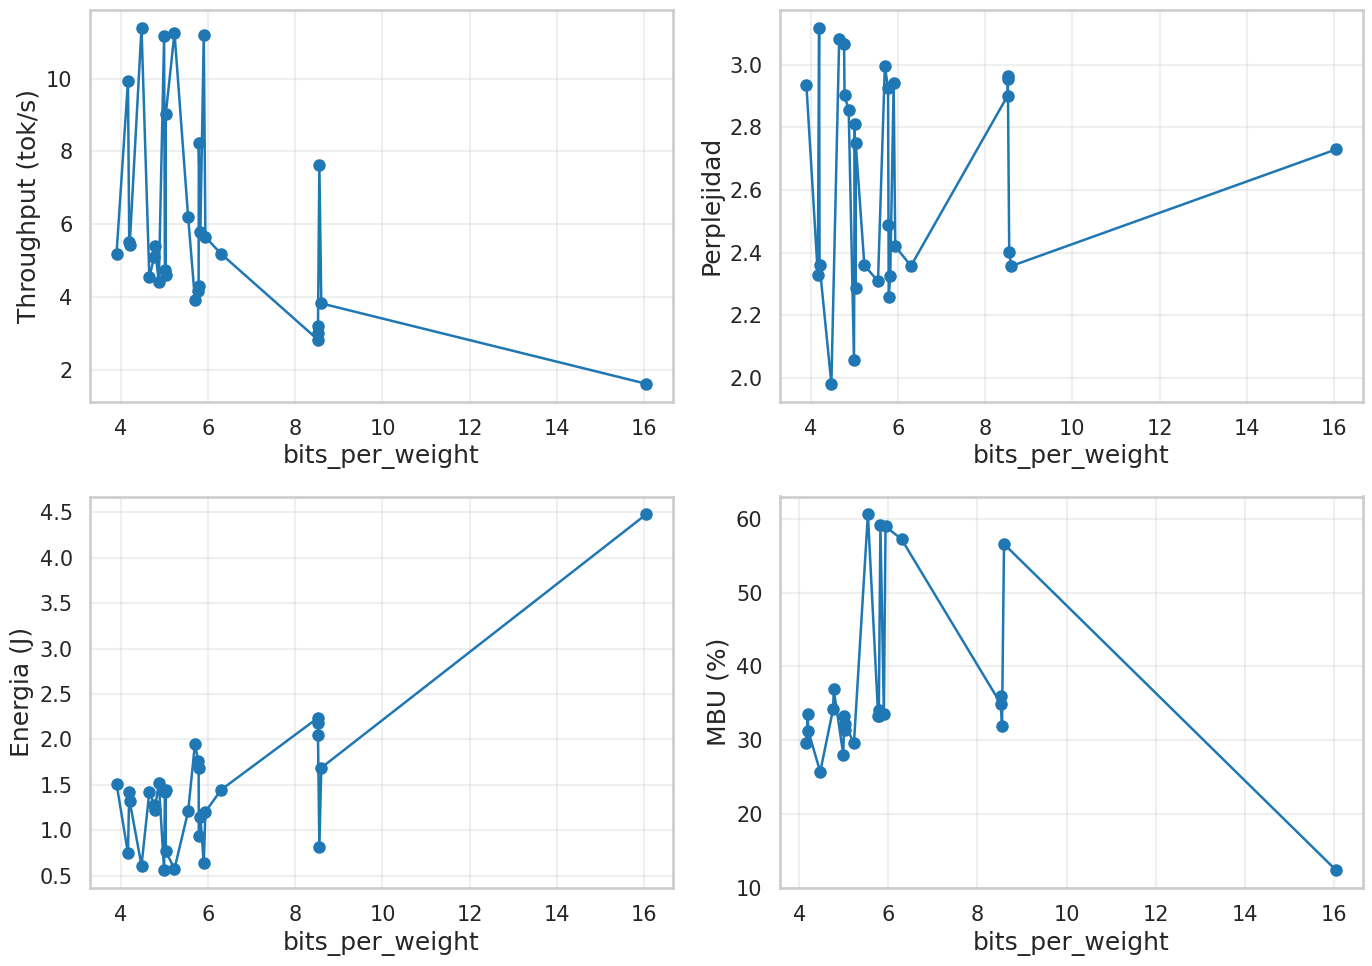

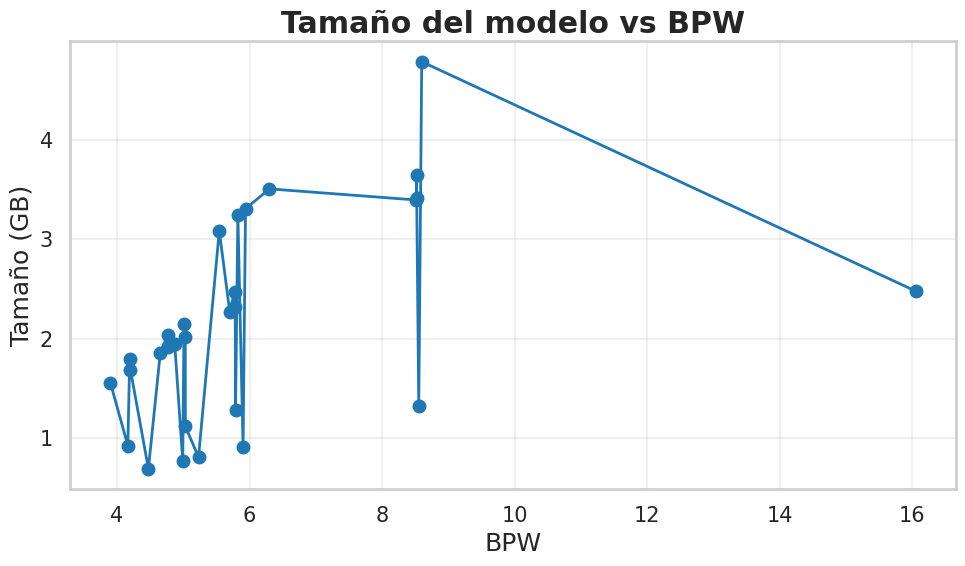

In [12]:
# Análisis específico E1: Sensitivity curve BPW
try:
    from monitorviz.viz import sensitivity_curve
    e1_ok = not ex.empty and "bits_per_weight" in ex.columns and ex["bits_per_weight"].nunique() >= 2
    if e1_ok:
        fig = sensitivity_curve(ex, param_col="bits_per_weight", metrics=[
            ("tokens_per_s_mean", "Throughput (tok/s)"),
            ("perplexity_geomean", "Perplejidad"),
            ("energy_per_token_j", "Energia (J)"),
            ("mbu_pct", "MBU (%)"),
        ])
        plt.show()
        if "model_size_gb" in ex.columns:
            size_bpw = ex.dropna(subset=["bits_per_weight", "model_size_gb"]).groupby("bits_per_weight")["model_size_gb"].mean()
            if not size_bpw.empty:
                fig, ax = plt.subplots(figsize=(10, 6))
                ax.plot(size_bpw.index, size_bpw.values, marker="o", linewidth=2)
                ax.set_xlabel("BPW")
                ax.set_ylabel("Tamaño (GB)")
                ax.set_title("Tamaño del modelo vs BPW")
                ax.grid(True, alpha=0.3)
                fig.tight_layout()
                plt.show()
    else:
        print("Sin datos de BPW")
except Exception as e:
    print(f"Error sensitivity_curve: {e}")

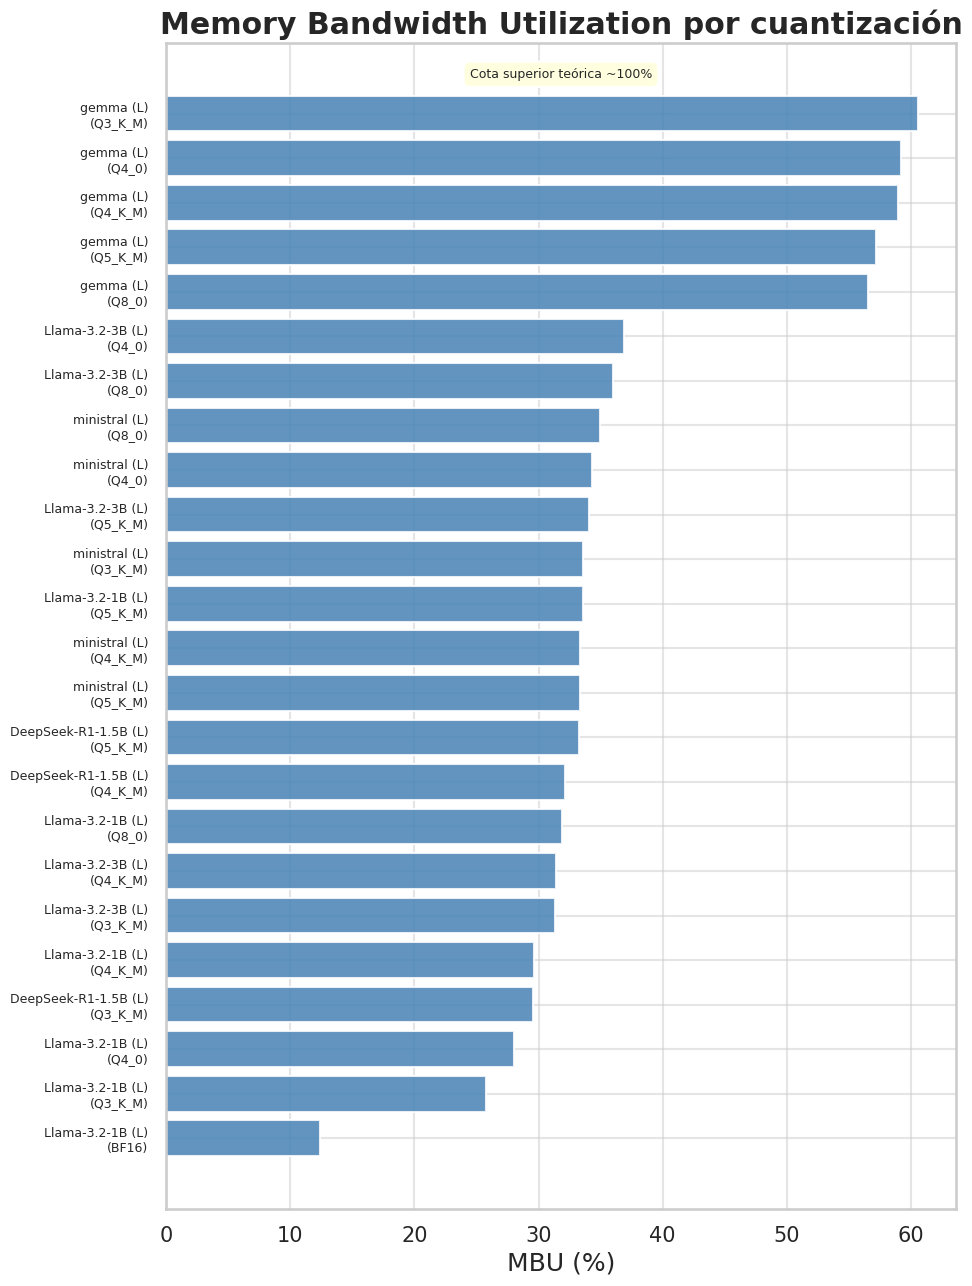

In [13]:
# MBU — Memory Bandwidth Utilization
if "mbu_pct" in ex.columns:
    mbu_data = ex.dropna(subset=["mbu_pct"])
    if not mbu_data.empty:
        order = (mbu_data.groupby("quant_label")["mbu_pct"]
                 .mean().sort_values(ascending=True).index)
        vals = mbu_data.groupby("quant_label")["mbu_pct"].mean().reindex(order)
        fig, ax = plt.subplots(figsize=(10, max(4, len(order) * 0.55)))
        ax.barh(range(len(order)), vals.values, alpha=0.85, color="steelblue")
        ax.set_yticks(range(len(order)))
        ax.set_yticklabels(order, fontsize=9)
        ax.set_xlabel("MBU (%)")
        ax.set_title("Memory Bandwidth Utilization por cuantización")
        ax.text(0.5, 0.97, "Cota superior teórica ~100%", transform=ax.transAxes,
                ha="center", fontsize=9,
                bbox=dict(boxstyle="round,pad=0.5", facecolor="lightyellow"))
        fig.tight_layout()
        plt.show()
    else:
        print("Sin datos de MBU")
else:
    print("Sin columna mbu_pct")


In [ ]:
# Trade-offs multidimensionales — Frontera de Pareto
def _pareto_front(df, x_col, y_col, x_lower, y_lower):
    """Filas no dominadas en el espacio (x_col, y_col).

    x_lower=True  → menor es mejor en X
    y_lower=True  → menor es mejor en Y
    """
    pts = df[[x_col, y_col]].to_numpy(dtype=float)
    n = len(pts)
    dominated = np.zeros(n, dtype=bool)
    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            x_ok = (pts[j, 0] <= pts[i, 0]) if x_lower else (pts[j, 0] >= pts[i, 0])
            y_ok = (pts[j, 1] <= pts[i, 1]) if y_lower else (pts[j, 1] >= pts[i, 1])
            strict = (pts[j, 0] != pts[i, 0]) or (pts[j, 1] != pts[i, 1])
            if x_ok and y_ok and strict:
                dominated[i] = True
                break
    return df[~dominated].sort_values(x_col)


pareto_pairs = [
    # (x_col,               y_col,                 x_label,            y_label,           x_lower, y_lower)
    ("tokens_per_s_mean",  "energy_per_token_j",  "Throughput (tok/s)", "Energía/token (J)", False,   True),
    ("perplexity_geomean", "tokens_per_s_mean",   "Perplejidad",        "Throughput (tok/s)", True,   False),
    ("energy_per_token_j", "perplexity_geomean",  "Energía/token (J)", "Perplejidad",         True,   True),
]
valid_pairs = [
    p for p in pareto_pairs
    if p[0] in ex.columns and p[1] in ex.columns
]

if valid_pairs and not ex.empty:
    _q_col_p = "quantization" if "quantization" in ex.columns else "model_short"
    _quants_p = [q for q in QUANT_ORDER if q in ex[_q_col_p].values]
    _models_p = sorted(ex["model_label"].unique())

    ncols = len(valid_pairs)
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6))
    if ncols == 1:
        axes = [axes]

    for ax, (x_col, y_col, xlabel, ylabel, x_lower, y_lower) in zip(axes, valid_pairs):
        data = ex.dropna(subset=[x_col, y_col]).reset_index(drop=True)
        if data.empty:
            ax.set_visible(False)
            continue

        scatter_e1(ax, data, x_col, y_col,
                   xlabel + (" ↓ mejor" if x_lower else " ↑ mejor"),
                   ylabel + (" ↓ mejor" if y_lower else " ↑ mejor"),
                   f"{xlabel} vs {ylabel}")

        front = _pareto_front(data, x_col, y_col, x_lower, y_lower)
        if not front.empty:
            ax.plot(front[x_col].values, front[y_col].values,
                    color="tab:red", ls="--", lw=1.5, zorder=2, label="Frontera Pareto")
            ax.legend(loc="best", fontsize=8)

    add_e1_legend(axes[-1], _quants_p, _models_p)
    fig.suptitle("E1 — Trade-offs multidimensionales (Frontera de Pareto)", fontsize=13, y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("Columnas insuficientes para Pareto:", [p[0] for p in pareto_pairs])

In [ ]:
# Desglose de fases (si hay datos)
try:
    from monitorviz.viz import phase_breakdown_stacked
    _run_ids_15 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    pm_valid = (pm_full[
        (pm_full["run_id"].isin(_run_ids_15)) &
        (~pm_full["is_empty_generation"]) &
        (pm_full["latency_ms"] > 0)
    ] if "run_id" in pm_full.columns else pd.DataFrame())
    if not pm_valid.empty and "phase_prompt_s" in pm_valid.columns:
        fig = phase_breakdown_stacked(ex, normalized=True)
        plt.show()
        fig = phase_breakdown_stacked(ex, normalized=False)
        plt.show()
    else:
        print("Sin datos de fases")
except Exception as e:
    print(f"Error en phase_breakdown: {e}")

In [ ]:
# Throttling heatmap
try:
    from monitorviz.viz import throttling_heatmap
    _run_ids_16 = ex["run_id"].tolist() if "run_id" in ex.columns else []
    hw_ex = hw_full[hw_full["run_id"].isin(_run_ids_16)] if "run_id" in hw_full.columns else pd.DataFrame()
    runs_ex = [r for r in coll.runs if r.run_id in _run_ids_16]
    if hw_ex.empty or not runs_ex:
        print("Sin datos de hardware para heatmap de throttling")
    else:
        fig = throttling_heatmap(hw_ex, runs_ex, bins=40,
                                 title="Heatmap de throttling")
        plt.show()
except Exception as e:
    print(f"Error en throttling_heatmap: {e}")

## Eficiencia computacional: trabajo CPU efectivo

- **W_CPU (core·s)**: integra `(f(t)/f_nom) x (CPU(t)/100) x N_cores x dt`
- **eta_CPU**: W_CPU / (N_cores x T), rango [0,1]
- **W_token (core·s/token)**: trabajo CPU por token generado

In [ ]:
# Eficiencia computacional y energética
def _plot_eff_e1(df, metric, title, unit_label=""):
    data = df.dropna(subset=[metric]).copy()
    order = (data.groupby("quant_label")[metric].mean()
             .sort_values().index.tolist())
    means = data.groupby("quant_label")[metric].mean().reindex(order)
    fig, ax = plt.subplots(figsize=(10, max(4, len(order) * 0.55)))
    ax.barh(range(len(order)), means.values, alpha=0.85, color="steelblue")
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(order, fontsize=9)
    ax.set_xlabel(unit_label or metric)
    ax.set_title(f"{title}" + (f" ({unit_label})" if unit_label else ""))
    fig.tight_layout()
    plt.show()

for col, ylabel, title in [
    ("cpu_work_core_s",    "core·s",       "Trabajo CPU efectivo por run"),
    ("cpu_efficiency",     "",             "Eficiencia CPU eta_CPU"),
    ("cpu_work_per_token", "core·s/token", "Trabajo CPU por token generado"),
]:
    if col in ex.columns:
        _plot_eff_e1(ex, col, title=title, unit_label=ylabel)

# Desglose por fases
try:
    phase_df = coll.cpu_work_by_phase_df() if hasattr(coll, "cpu_work_by_phase_df") else pd.DataFrame()
    phase_df_ex = phase_df[phase_df["run_id"].isin(ex["run_id"])] if not phase_df.empty else pd.DataFrame()
    if not phase_df_ex.empty:
        phase_df_ex = phase_df_ex.copy()
        phase_df_ex["quant_label"] = phase_df_ex["run_id"].map(_ql_map)
        fig, ax = plt.subplots(figsize=(10, max(4, phase_df_ex["quant_label"].nunique() * 0.55)))
        phase_df_ex.groupby(["quant_label", "phase"])["cpu_work_core_s"].mean().unstack().plot(
            kind="barh", ax=ax)
        ax.set_title("W_CPU por fase y cuantización")
        ax.set_ylabel("")
        fig.tight_layout()
        plt.show()
except Exception as e:
    print(f"cpu_work_by_phase_df: {e}")

if "energy_per_token_j" in ex.columns:
    _plot_eff_e1(ex, "energy_per_token_j", title="Energía por token", unit_label="J/token")

# Scatter CPU vs Potencia
if "cpu_work_core_s" in ex.columns and "power_mean_w" in ex.columns:
    valid_data = ex.dropna(subset=["cpu_work_core_s", "power_mean_w"])
    if not valid_data.empty:
        _q_col_e = "quantization" if "quantization" in valid_data.columns else "model_short"
        fig, ax = plt.subplots(figsize=(12, 6))
        scatter_e1(ax, valid_data, "cpu_work_core_s", "power_mean_w",
                   "W_CPU (core·s)", "Potencia media (W)", "Relación W_CPU — Potencia")
        _quants_e = [q for q in QUANT_ORDER if q in valid_data[_q_col_e].values]
        _models_e = sorted(valid_data["model_label"].unique())
        add_e1_legend(ax, _quants_e, _models_e)
        fig.tight_layout()
        plt.show()


In [ ]:
# Rendimiento vs BPW
if "bits_per_weight" in ex.columns and ex["bits_per_weight"].notna().any():
    bpw_data = ex.dropna(subset=["bits_per_weight"])
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    scatter_e1(axes[0], bpw_data, "bits_per_weight", "tokens_per_s_mean",
               "BPW", "tokens/s", "Throughput vs BPW")

    ppl_bpw = bpw_data.dropna(subset=["perplexity_geomean"])
    if not ppl_bpw.empty:
        scatter_e1(axes[1], ppl_bpw, "bits_per_weight", "perplexity_geomean",
                   "BPW", "Perplejidad (geomedia)", "Perplejidad vs BPW")
    else:
        axes[1].set_visible(False)

    _quants_s = [q for q in QUANT_ORDER if q in bpw_data[_q_col_s].values]
    _models_s = sorted(bpw_data["model_label"].unique())
    _legend_ax = axes[1] if not ppl_bpw.empty else axes[0]
    add_e1_legend(_legend_ax, _quants_s, _models_s)

    fig.suptitle("Rendimiento vs cuantización (BPW)", y=1.02)
    fig.tight_layout()
    plt.show()
else:
    print("Sin datos BPW para scatter")


In [ ]:
# Diagramas polares — par (rendimiento + hardware) por cuantización
from matplotlib.lines import Line2D as _L2D

PERF_METRICS = [
    ("tokens_per_s_mean",  "Throughput\n(tok/s)", True),
    ("ttft_ms_mean",       "TTFT",                False),
    ("perplexity_geomean", "Perplejidad",          False),
    ("energy_per_token_j", "Energía/token",        False),
]
HW_METRICS = [
    ("mbu_pct",        "MBU (%)",   True),
    ("temp_max_c",     "Temp máx", False),
    ("power_mean_w",   "Potencia",  False),
    ("cpu_efficiency", "η_CPU",     True),
]

_q_col_r = "quantization" if "quantization" in ex.columns else "model_short"

# Colores por modelo (ciclo de la paleta activa)
_model_list_r   = sorted(ex["model_label"].dropna().unique())
_color_cycle_r  = plt.rcParams["axes.prop_cycle"].by_key()["color"]
MODEL_COLORS_R  = {m: _color_cycle_r[i % len(_color_cycle_r)]
                   for i, m in enumerate(_model_list_r)}


def _radar_axes(ax, avail_metrics, title):
    """Configura los ejes polares comunes."""
    N      = len(avail_metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_xticks(angles)
    ax.set_xticklabels([m[1] for m in avail_metrics], size=8)
    ax.set_ylim(0, 1)
    ax.grid(color="gray", alpha=0.3)
    ax.set_title(title, pad=15, fontweight="bold", fontsize=10)
    return angles


def _norm_vals(row, avail_metrics):
    """Devuelve lista de valores normalizados [0,1] para una fila."""
    vals = []
    for col, _, higher_is_better in avail_metrics:
        col_min = ex[col].min() if col in ex.columns else 0.0
        col_max = ex[col].max() if col in ex.columns else 1.0
        rng = col_max - col_min if col_max != col_min else 1.0
        raw = row.get(col, np.nan)
        v   = 0.0 if pd.isna(raw) else np.clip((raw - col_min) / rng, 0.0, 1.0)
        vals.append(v if higher_is_better else 1.0 - v)
    return vals


def _radar_fig(metrics, title, ex_df):
    """Un panel por modelo; líneas coloreadas por cuantización."""
    avail  = [m for m in metrics if m[0] in ex_df.columns]
    models = sorted(ex_df["model_label"].dropna().unique())
    if not models or not avail:
        print(f"Sin datos para: {title}"); return
    ncols = min(len(models), 4)
    nrows = (len(models) + ncols - 1) // ncols
    fig   = plt.figure(figsize=(5 * ncols, 5 * nrows + 1))
    for k, model in enumerate(models):
        ax     = fig.add_subplot(nrows, ncols, k + 1, polar=True)
        subset = ex_df[ex_df["model_label"] == model]
        if subset.empty:
            ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off(); continue
        angles = _radar_axes(ax, avail, model)
        angles_c = angles + angles[:1]
        for _, row in subset.iterrows():
            vals  = _norm_vals(row, avail)
            color = QUANT_COLORS.get(str(row.get(_q_col_r, "")), "gray")
            ax.plot(angles_c, vals + vals[:1], lw=2, color=color, alpha=0.9)
            ax.fill(angles_c, vals + vals[:1], alpha=0.12, color=color)
    quants_in_fig = [q for q in QUANT_ORDER if q in ex_df[_q_col_r].values]
    quants_in_fig += [q for q in ex_df[_q_col_r].dropna().unique() if q not in quants_in_fig]
    handles = [_L2D([0],[0], color=QUANT_COLORS.get(q,"gray"), lw=2, label=q)
               for q in quants_in_fig]
    fig.legend(handles=handles, loc="lower center", ncol=len(handles),
               fontsize=9, title="Cuantización", title_fontsize=9,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title + "  (exterior = mejor)", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


def _radar_fig_t(metrics, title, ex_df):
    """Versión transpuesta: un panel por cuantización; líneas coloreadas por modelo."""
    avail  = [m for m in metrics if m[0] in ex_df.columns]
    quants = [q for q in QUANT_ORDER if q in ex_df[_q_col_r].values]
    quants += [q for q in ex_df[_q_col_r].dropna().unique() if q not in quants]
    if not quants or not avail:
        print(f"Sin datos para: {title}"); return
    ncols = min(len(quants), 4)
    nrows = (len(quants) + ncols - 1) // ncols
    fig   = plt.figure(figsize=(5 * ncols, 5 * nrows + 1))
    for k, q in enumerate(quants):
        ax     = fig.add_subplot(nrows, ncols, k + 1, polar=True)
        subset = ex_df[ex_df[_q_col_r] == q]
        if subset.empty:
            ax.text(0.5, 0.5, "Sin datos", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off(); continue
        angles = _radar_axes(ax, avail, q)
        angles_c = angles + angles[:1]
        for _, row in subset.iterrows():
            vals  = _norm_vals(row, avail)
            color = MODEL_COLORS_R.get(str(row.get("model_label", "")), "gray")
            ax.plot(angles_c, vals + vals[:1], lw=2, color=color, alpha=0.9)
            ax.fill(angles_c, vals + vals[:1], alpha=0.12, color=color)
    handles = [_L2D([0],[0], color=MODEL_COLORS_R.get(m,"gray"), lw=2, label=m)
               for m in _model_list_r if m in ex_df["model_label"].values]
    fig.legend(handles=handles, loc="lower center", ncol=min(len(handles), 4),
               fontsize=9, title="Modelo", title_fontsize=9,
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle(title + "  (exterior = mejor)", fontsize=13, y=1.02)
    plt.tight_layout(); plt.show()


# ── Versión A: panel por modelo, líneas por cuantización ─────────────────────
_radar_fig(PERF_METRICS, "Rendimiento — panel por modelo",   ex)
_radar_fig(HW_METRICS,   "Hardware    — panel por modelo",   ex)

# ── Versión B (transpuesta): panel por cuantización, líneas por modelo ────────
_radar_fig_t(PERF_METRICS, "Rendimiento — panel por cuantización", ex)
_radar_fig_t(HW_METRICS,   "Hardware    — panel por cuantización", ex)


In [ ]:
# Correlación de Pearson con BPW como primera variable
PEARSON_VARS = [
    "bits_per_weight",
    "tokens_per_s_mean", "words_per_s_mean", "latency_ms_mean",
    "ttft_ms_mean", "eval_count_mean",
    "perplexity_geomean",
    "temp_max_c", "power_mean_w", "energy_per_token_j", "cpu_work_core_s",
]
BLOCK_SIZES = [1, 6, 1, 4]
PEARSON_LABELS = {
    "bits_per_weight":    "BPW",
    "tokens_per_s_mean":  "tok/s",
    "words_per_s_mean":   "words/s",
    "latency_ms_mean":    "Latencia",
    "ttft_ms_mean":       "TTFT",
    "eval_count_mean":    "Tokens gen.",
    "perplexity_geomean": "Perplejidad",
    "temp_max_c":         "Temp max",
    "power_mean_w":       "Potencia",
    "energy_per_token_j": "J/token",
    "cpu_work_core_s":    "W_CPU",
}

if len(ex) >= 3:
    avail = [v for v in PEARSON_VARS if v in ex.columns]
    if len(avail) >= 2:
        corr_data = ex[avail].dropna(how="all")
        corr_mat  = corr_data.corr(method="pearson")
        labels    = [PEARSON_LABELS.get(v, v) for v in avail]

        fig, ax = plt.subplots(figsize=(max(8, len(avail) * 0.75),
                                        max(7, len(avail) * 0.65)))
        im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xticks(range(len(avail)))
        ax.set_yticks(range(len(avail)))
        ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
        ax.set_yticklabels(labels, fontsize=9)
        ax.grid(False)  # evita líneas de cuadrícula sobre el heatmap
        for i in range(len(avail)):
            for j in range(len(avail)):
                v = corr_mat.iloc[i, j]
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        fontsize=7, color="white" if abs(v) > 0.6 else "black")

        # Block separators
        cum = 0
        for size in BLOCK_SIZES:
            cum += size
            if cum < len(avail):
                ax.axhline(cum - 0.5, color="white", lw=2)
                ax.axvline(cum - 0.5, color="white", lw=2)

        ax.set_title(f"Correlación Pearson (n={len(corr_data)} runs)", fontsize=12)
        fig.tight_layout()
        plt.show()

        # Tabla: correlaciones con BPW
        if "bits_per_weight" in avail:
            bpw_corr = (corr_mat["bits_per_weight"]
                        .drop("bits_per_weight")
                        .sort_values(key=abs, ascending=False))
            bpw_df = bpw_corr.reset_index()
            bpw_df.columns = ["Variable", "Corr. con BPW"]
            bpw_df["Variable"] = bpw_df["Variable"].map(
                lambda x: PEARSON_LABELS.get(x, x))
            bpw_df["Corr. con BPW"] = bpw_df["Corr. con BPW"].round(3)
            print("\nCorrelaciones con bits_per_weight:")
            display(bpw_df)
    else:
        print(f"Variables insuficientes: {avail}")
else:
    print(f"Datos insuficientes: {len(ex)} run(s), se necesitan >=3.")


In [ ]:
# Alertas y anomalías
alerts = []
if "throttled_ratio" in ex.columns:
    for _, row in ex[ex["throttled_ratio"] > 0.5].iterrows():
        alerts.append(f"throttling: {row['model_label']} ({row['throttled_ratio']*100:.1f}%)")
if "n_empty_generations" in ex.columns:
    for _, row in ex[ex["n_empty_generations"] > 0].iterrows():
        alerts.append(f"generaciones vacias: {row['model_label']} (n={int(row['n_empty_generations'])})")
if "tokens_per_s_mean" in ex.columns and len(ex) >= 3:
    mean_tps = ex["tokens_per_s_mean"].mean()
    std_tps  = ex["tokens_per_s_mean"].std()
    for _, row in ex[(ex["tokens_per_s_mean"] > mean_tps + 2 * std_tps) |
                     (ex["tokens_per_s_mean"] < mean_tps - 2 * std_tps)].iterrows():
        alerts.append(f"outlier throughput: {row['model_label']} ({row['tokens_per_s_mean']:.2f} tok/s)")
for a in alerts:
    print(f"ALERTA: {a}")
if not alerts:
    print("Sin alertas detectadas")

## Conclusiones y discusión

### Confirmación/refutación de hipótesis
> TODO

### Hallazgos principales
> TODO

### Limitaciones
> TODO